In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')


SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 04b · Chọn quán quân & chốt tập đặc trưng

Mảnh thứ hai. Nhận 6 mô hình đã huấn luyện từ `04a`, và kết thúc bằng việc **khóa mọi quyết định** trước khi bất kỳ ai được phép mở `rct_holdout`.

Bốn việc:

1. Dựng bộ metric cho tập RCT và **kiểm chứng bằng bốn phép thử ngược** trước khi dùng
2. Đấu 6 mô hình trên `rct_select` để chọn quán quân, kèm bootstrap theo cặp
3. Đo độ quan trọng đặc trưng bằng **hai cách độc lập** — gain và permutation — rồi quét số đặc trưng giữ lại, **huấn luyện lại mô hình trên đúng từng tập đặc trưng**
4. Đóng băng quán quân + tập đặc trưng vào `decisions_locked.json` kèm mã băm

### Notebook này KHÔNG nạp `rct_holdout.parquet`

Đó là điểm mấu chốt của việc tách ba mảnh. Mọi quyết định nằm ở đây, mọi phép đo cuối nằm ở 04c, và ranh giới giữa hai bên là một file được băm chứ không phải một lời hứa trong markdown.

### Ablation phải huấn luyện lại, không được điền giá trị mặc định

Bản trước có bước "ablation lúc phục vụ": giữ nguyên mô hình đầy đủ rồi thay các cột ngoài top-k bằng trung vị. Cách đó **không trả lời câu hỏi nào có ý nghĩa** — nó chỉ đo mô hình nhạy tới đâu với việc bị bơm giá trị giả, và tất nhiên những cột mô hình chưa từng chia nhánh thì thay gì cũng cho sai lệch bằng 0. Ở đây mỗi mức k đều **huấn luyện lại mô hình trên đúng tập k đặc trưng đó**.

### Đầu ra

| File | Nội dung |
|---|---|
| `artifacts/decisions_locked.json` | Quán quân, siêu tham số, tập đặc trưng bàn giao, mã băm |
| `artifacts/04b_model_ban_giao.pkl` | Đúng mô hình sẽ được bàn giao |
| `artifacts/04b_select_meta.json` | Bảng xếp hạng, hai bảng độ quan trọng, bảng quét k |

---
# Phần 1 — Thiết lập

### Bước 1 — Import thư viện

In [2]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q econml optuna mlflow')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3

In [3]:
import os
import json
import time
import pickle
import hashlib
import uuid
import cloudpickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from econml.dml import LinearDML, NonParamDML, CausalForestDML

warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("📌 Đang chạy trên Kaggle Environment")
    # Không gõ cứng đường dẫn: Kaggle mount dataset ở chỗ khác nhau tuỳ cách gắn.
    # Tìm thẳng thư mục nào chứa train.parquet.
    import glob
    _ung_vien = [os.path.dirname(f) for f in
                 glob.glob('/kaggle/input/**/train.parquet', recursive=True)]
    if not _ung_vien:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra đã gắn dataset chưa.')
    DATA_DIR = _ung_vien[0]
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print("📌 Đang chạy trên máy Local")
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# np.trapz đã đổi tên ở NumPy 2 — dùng bản nào có sẵn
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"DATA_DIR: {DATA_DIR}")
print(f"ART_DIR : {ART_DIR}")

📌 Đang chạy trên Kaggle Environment
DATA_DIR: /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR : /kaggle/working/artifacts


In [4]:
import glob


def tim_file(ten, bat_buoc=True):
    """Tìm một file bàn giao: ưu tiên artifacts local, rồi tới output kernel khác trên Kaggle.

    Trên Kaggle, đầu ra của notebook trước được gắn vào qua kernel_sources và nằm
    dưới /kaggle/input/<slug>/. Tìm thấy nhiều bản thì in hết ra — hai bản khác nhau
    nghĩa là đang có bản cũ lẫn vào, và chọn nhầm bản cũ là lỗi không báo gì cả.
    """
    ung_vien = [os.path.join(ART_DIR, ten)]
    ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        if bat_buoc:
            raise FileNotFoundError(
                f'Không tìm thấy {ten}. Chạy notebook sinh ra nó trước, hoặc gắn output '
                'của kernel đó vào qua kernel_sources.')
        return None
    if len(ung_vien) > 1:
        print(f'!!! Tìm thấy {len(ung_vien)} bản {ten} — kiểm tra có bản cũ lẫn vào không:')
        for p in ung_vien:
            print('   ', p)
    return ung_vien[0]


def bam_dac_trung(feats):
    """Vân tay của tập đặc trưng — ba notebook phải khớp nhau."""
    return hashlib.sha256(','.join(feats).encode()).hexdigest()[:16]


print('Đã định nghĩa tim_file và bam_dac_trung')

Đã định nghĩa tim_file và bam_dac_trung


### Bước 2 — Chế độ chạy

Hai nhóm hằng số quyết định thời gian chạy của notebook này:

- **`N_PERM_REPEAT` / `N_PERM_ROWS`** — permutation importance gọi `predict` một lần cho mỗi đặc trưng × mỗi lần xáo. 69 đặc trưng × 5 lần xáo là 345 lần dự đoán.
- **`N_FIT_QUET` / `N_K_GRID`** — vòng quét k **huấn luyện lại mô hình quán quân một lần cho mỗi mức k**. Đây thường là phần tốn thời gian nhất của cả notebook.

> **Vì sao vòng quét có trần riêng, không dùng lại cỡ mẫu của 04a.** Vòng quét chỉ trả lời *"bỏ bớt đặc trưng thì mô hình xấu đi bao nhiêu"* — một phép so **tương đối** giữa các mức k. Phép so đó vẫn có nghĩa ở cỡ mẫu nhỏ hơn, trong khi chi phí giảm theo đúng tỉ lệ. Nếu quán quân là `CausalForestDML` học trên toàn bộ 926 nghìn dòng thì quét 6 mức k đồng nghĩa với 6 lần huấn luyện đầy đủ — vượt xa giới hạn 12 giờ của một kernel Kaggle.
>
> Đổi lại phải giữ một kỷ luật, và Bước 23 thực thi nó: **mốc so sánh của vòng quét là mốc `k = 69` của chính vòng quét đó**, huấn luyện ở cùng `N_FIT_QUET`, chứ không phải mô hình của 04a. So mô hình rút gọn học 200 nghìn dòng với mô hình đầy đủ học 926 nghìn dòng thì chênh lệch trộn cả "ít đặc trưng hơn" lẫn "ít dữ liệu hơn" — đúng cái lỗi mà cả pipeline đang tránh.

In [5]:
# Mặc định chạy nhanh. Đổi bằng biến môi trường, không sửa notebook:
#     SMOKE_TEST=0  ->  chế độ đầy đủ.  Trên Kaggle: %env SMOKE_TEST=0
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

if SMOKE_TEST:
    N_BOOT = 100
    N_PERM_REPEAT, N_PERM_ROWS = 2, 30_000
    N_K_GRID, N_FIT_QUET = 4, 20_000
else:
    N_BOOT = 1_000
    N_PERM_REPEAT, N_PERM_ROWS = 5, None
    N_K_GRID, N_FIT_QUET = 5, 200_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 68)
print(f'  04b — CHỌN QUÁN QUÂN   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Bootstrap             : {N_BOOT:,} lần')
print(f'  Permutation importance: {N_PERM_REPEAT} lần xáo mỗi đặc trưng, '
      f'trên {"toàn bộ rct_select" if N_PERM_ROWS is None else f"{N_PERM_ROWS:,} dòng"}')
print(f'  Vòng quét k           : {N_K_GRID} mức + mốc đầy đủ, '
      f'mỗi mức huấn luyện lại trên tối đa {N_FIT_QUET:,} dòng')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 68)

  04b — CHỌN QUÁN QUÂN   |   CHẾ ĐỘ: FULL
  Bootstrap             : 1,000 lần
  Permutation importance: 5 lần xáo mỗi đặc trưng, trên toàn bộ rct_select
  Vòng quét k           : 5 mức + mốc đầy đủ, mỗi mức huấn luyện lại trên tối đa 200,000 dòng


### Bước 3 — Nạp kết quả của 04a

Ba thứ phải khớp trước khi đi tiếp, nếu không là đang ghép kết quả của hai lần chạy khác nhau:

- **`run_id` của 04a** — ghi lại để 04c đối chiếu chuỗi 04a → 04b → 04c.
- **Mã băm tập đặc trưng** — 04a phải huấn luyện trên đúng danh sách cột mà notebook này đang đọc.
- **`cung_co_mau`** — nếu 6 mô hình học trên số dòng khác nhau thì bảng xếp hạng ở Phần 3 trộn chất lượng phương pháp với lượng dữ liệu, và ô lệnh sẽ cảnh báo.

In [6]:
# --- đầu ra của 04a ---
train_meta = json.load(open(tim_file('04a_train_meta.json'), encoding='utf-8'))
cate_npz = np.load(tim_file('04a_cate_select.npz'))
cate_sel = {k: cate_npz[k] for k in cate_npz.files}

RUN_ID_04A = train_meta['run_id']
MODELS = ['SLearner', 'TLearner', 'DRLearner',
          'LinearDML', 'NonParamDML', 'CausalForestDML']
OK_MODELS = [m for m in MODELS if m in cate_sel]
thoi_gian = {m: train_meta['mo_hinh'][m]['giay'] for m in OK_MODELS}
n_dong_fit = {m: train_meta['mo_hinh'][m]['so_dong_huan_luyen'] for m in OK_MODELS}

# --- tham số của notebook 03 ---
tuning = json.load(open(tim_file('best_params.json'), encoding='utf-8'))
BEST = tuning['best_params']
E_ALPHA = float(tuning['xu_ly_overlap']['propensity_alpha'])
E_CLIP = (E_ALPHA, 1 - E_ALPHA)

# --- đặc trưng và dữ liệu ---
finfo = json.load(open(tim_file('feature_info.json'), encoding='utf-8'))
FEATS = finfo['tat_ca_dac_trung']
N_FEAT = len(FEATS)

train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
rct_sel = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))

# --- chốt cổng ---
assert N_FEAT == 69 and not any(c.startswith('fe_') for c in FEATS)
assert train_meta['ma_bam_dac_trung'] == bam_dac_trung(FEATS), \
    '04a huấn luyện trên một tập đặc trưng khác — chạy lại 04a'
assert tuning['cau_hinh']['feature_names'] == FEATS
for ten, d in [('train', train), ('val', val), ('rct_select', rct_sel)]:
    assert list(d.columns) == ['data_id', 'is_treat', 'label'] + FEATS, f'{ten}: sai thứ tự cột'
for m in OK_MODELS:
    assert len(cate_sel[m]) == len(rct_sel)

print(f'run_id của 04a    : {RUN_ID_04A}')
print(f'run_mode          : 04a = {train_meta["run_mode"]} | notebook 03 = {tuning["run_mode"]}')
print(f'Mô hình có kết quả: {len(OK_MODELS)}/{len(MODELS)}')
print(f'Đặc trưng         : {N_FEAT} (mã băm khớp)')
print(f'rct_select        : {len(rct_sel):,} dòng')
print('rct_holdout       : KHÔNG nạp ở notebook này')
print()
display(pd.DataFrame([{'Mô hình': m, 'Dòng huấn luyện': f'{n_dong_fit[m]:,}',
                       'Giây': thoi_gian[m]} for m in OK_MODELS]))
if not train_meta['cung_co_mau']:
    print('>>> CẢNH BÁO: sáu mô hình học trên số dòng KHÁC nhau. Bảng xếp hạng phía dưới trộn')
    print('    chất lượng phương pháp với lượng dữ liệu — phải nói rõ điều này khi báo cáo. <<<')
if train_meta['mo_hinh_loi']:
    print('>>> Mô hình lỗi ở 04a:', train_meta['mo_hinh_loi'])

run_id của 04a    : full-20260819-024811-f35fc7
run_mode          : 04a = full | notebook 03 = full
Mô hình có kết quả: 6/6
Đặc trưng         : 69 (mã băm khớp)
rct_select        : 90,834 dòng
rct_holdout       : KHÔNG nạp ở notebook này



,Mô hình,Dòng huấn luyện,Giây
0,SLearner,"926,669",11.0
1,TLearner,"926,669",20.8
2,DRLearner,"926,669",213.6
3,LinearDML,"926,669",171.7
4,NonParamDML,"926,669",86.0
5,CausalForestDML,"926,669",1861.6


In [7]:
_cache_mo_hinh = {}


def nap_mo_hinh(ten):
    """Nạp mô hình 04a đã huấn luyện. Nạp lười vì mỗi file có thể khá nặng."""
    if ten not in _cache_mo_hinh:
        with open(tim_file(f'04a_model_{ten}.pkl'), 'rb') as f:
            _cache_mo_hinh[ten] = pickle.load(f)
    return _cache_mo_hinh[ten]


print('Đã định nghĩa nap_mo_hinh — đọc 04a_model_<tên>.pkl')

Đã định nghĩa nap_mo_hinh — đọc 04a_model_<tên>.pkl


---
# Phần 2 — Bộ metric và bốn phép kiểm chứng

Đây là phần quan trọng nhất của notebook, và là phần phải làm **trước** khi nhìn bất kỳ kết quả mô
hình nào. Lý do đơn giản: nếu công thức Qini sai thì mọi kết luận rút ra từ nó cũng sai theo, mà cái
sai đó rất khó phát hiện vì bảng kết quả vẫn in ra những con số trông hợp lý.

Cách phòng: viết metric xong thì thử ngược bằng những trường hợp đã biết trước đáp án.

### Bước 4 — Đường Qini và đường Cumulative Gain

Cả hai đường đều xây theo cùng một ý tưởng: sắp khách hàng giảm dần theo CATE dự đoán, rồi hỏi
*"nếu chỉ phát voucher cho k% đứng đầu thì được thêm bao nhiêu đơn hàng?"*.

Vướng mắc là trong nhóm k% đó có cả người thực sự nhận voucher lẫn người không, và số lượng hai
nhóm không bằng nhau. Hai đường xử lý chuyện đó theo hai cách khác nhau:

$$\text{Qini}(k) = Y^T_k - Y^C_k \cdot \frac{N^T_k}{N^C_k}
\qquad
\text{Gain}(k) = \left(\frac{Y^T_k}{N^T_k} - \frac{Y^C_k}{N^C_k}\right)(N^T_k + N^C_k)$$

Qini quy số đơn của nhóm control về cùng cỡ với nhóm treatment. Cumulative Gain lấy hiệu hai *tỉ lệ*
rồi nhân ngược lên cỡ nhóm. Khi hai nhóm cân bằng thì hai đường gần trùng nhau; khi lệch nhiều thì
Qini ổn định hơn ở đầu đường cong, nên nó được chọn làm metric chính.

Hai chi tiết kỹ thuật:

- **Phá thế hòa có seed.** Nhiều mô hình cho ra CATE trùng nhau ở hàng loạt dòng. Nếu để `argsort`
  tự xử thì thứ tự phụ thuộc thứ tự dòng trong file, và một mô hình dự đoán hằng số có thể ăn may
  điểm cao. Xáo ngẫu nhiên trong nhóm hòa, có seed để chạy lại ra đúng kết quả cũ.
- **Chia cho cỡ mẫu.** Đường cong tính theo số đơn tuyệt đối sẽ phụ thuộc cỡ tập. Chia cho `n` để
  so sánh được giữa `rct_select` và `rct_holdout`.

In [8]:
def _sap_xep(y, w, score, seed=SEED):
    '''Sắp giảm dần theo score, phá thế hòa ngẫu nhiên có seed.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return (np.cumsum(w_), np.cumsum(1 - w_),
            np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_)))


def qini_curve(y, w, score, seed=SEED):
    '''Trả về (x = tỉ lệ dân số được nhắm, y = số đơn tăng thêm trên mỗi người).'''
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    n = len(y)
    ty_le = np.divide(nt, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (yt - yc * ty_le) / n


def gain_curve(y, w, score, seed=SEED):
    n = len(y)
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    r_t = np.divide(yt, nt, out=np.zeros(n), where=nt > 0)
    r_c = np.divide(yc, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (r_t - r_c) * (nt + nc) / n


print('Đã định nghĩa qini_curve và gain_curve')

Đã định nghĩa qini_curve và gain_curve


### Bước 5 — Hệ số Qini và AUUC

Đường cong là một dãy số, cần thu về một con số duy nhất để xếp hạng.

Mốc so sánh là **đường chéo ngẫu nhiên**: nếu phát voucher cho một nhóm ngẫu nhiên k% thì thu được
đúng k% của tổng hiệu ứng, tức một đường thẳng nối gốc tọa độ tới điểm cuối. Diện tích giữa đường
cong của mô hình và đường chéo đó chính là phần giá trị mà việc xếp hạng mang lại.

Diện tích thô có đơn vị "đơn hàng trên mỗi người", cỡ khoảng $10^{-4}$ trên bộ dữ liệu này —
đúng nhưng khó đọc. Nên chia thêm cho diện tích của một **xếp hạng biết trước đáp án**:

```
score_oracle = +1 nếu (nhận voucher và có mua)
               -1 nếu (không nhận voucher mà vẫn mua)
                0 còn lại
```

Xếp hạng này đẩy toàn bộ người "mua khi có voucher" lên đầu và người "mua kể cả khi không có voucher"
xuống cuối, tức là đường Qini dốc nhất có thể đạt được trên chính tập dữ liệu đó. Nó nhìn vào nhãn
thật nên không phải mô hình — chỉ là **trần trên** để quy về thang 0–1.

Với cách chuẩn hóa này: xếp hạng ngẫu nhiên cho khoảng 0, xếp hạng biết trước cho đúng 1,0. Mô hình
thật nằm đâu đó ở giữa, và con số đọc ra là *"đạt được bao nhiêu phần trăm của mức tốt nhất có thể"*.

In [9]:
def oracle_score(y, w):
    '''Xếp hạng biết trước đáp án — trần trên để chuẩn hóa, không phải mô hình.'''
    return np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)


def _dien_tich_tren_duong_cheo(x, g):
    '''Diện tích giữa đường cong và đường chéo ngẫu nhiên.'''
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def qini_tho(y, w, score, seed=SEED):
    return _dien_tich_tren_duong_cheo(*qini_curve(y, w, score, seed))


def qini_score(y, w, score, seed=SEED):
    '''Hệ số Qini chuẩn hóa — metric chính. Ngẫu nhiên ≈ 0, biết trước = 1.'''
    tran = qini_tho(y, w, oracle_score(y, w), seed)
    return qini_tho(y, w, score, seed) / tran if tran > 0 else np.nan


def auuc_score(y, w, score, seed=SEED):
    '''Tương tự nhưng trên đường Cumulative Gain — dùng để đối chiếu.'''
    x, g = gain_curve(y, w, score, seed)
    xo, go = gain_curve(y, w, oracle_score(y, w), seed)
    tran = _dien_tich_tren_duong_cheo(xo, go)
    return _dien_tich_tren_duong_cheo(x, g) / tran if tran > 0 else np.nan


print('Đã định nghĩa qini_score và auuc_score')

Đã định nghĩa qini_score và auuc_score


### Bước 6 — ATE kèm khoảng tin cậy

Trên tập RCT, việc phát voucher là ngẫu nhiên nên hiệu hai tỉ lệ chuyển đổi đã là ước lượng không
chệch cho ATE, không cần hiệu chỉnh gì thêm. Sai số chuẩn theo công thức hiệu hai tỉ lệ:

$$\widehat{SE} = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_0(1-p_0)}{n_0}}$$

In [10]:
def ate_with_ci(y, w, alpha=0.05):
    '''ATE, sai số chuẩn và khoảng tin cậy trên tập RCT.'''
    y = np.asarray(y, dtype=float)
    w = np.asarray(w)
    y1, y0 = y[w == 1], y[w == 0]
    p1, p0 = y1.mean(), y0.mean()
    se = np.sqrt(p1 * (1 - p1) / len(y1) + p0 * (1 - p0) / len(y0))
    z = stats.norm.ppf(1 - alpha / 2)
    ate = p1 - p0
    return {'ate': float(ate), 'se': float(se),
            'ci_thap': float(ate - z * se), 'ci_cao': float(ate + z * se),
            'n_treat': int(len(y1)), 'n_control': int(len(y0))}


def uplift_at_k(y, w, score, k=0.2, seed=SEED):
    '''Uplift thực đo trong nhóm k% có CATE dự đoán cao nhất.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    top = order[:max(1, int(round(k * n)))]
    yt, wt = np.asarray(y)[top], np.asarray(w)[top]
    if wt.sum() == 0 or (1 - wt).sum() == 0:
        return np.nan
    return float(yt[wt == 1].mean() - yt[wt == 0].mean())


print('Đã định nghĩa ate_with_ci và uplift_at_k')

Đã định nghĩa ate_with_ci và uplift_at_k


### Bước 7 — Khoảng tin cậy bootstrap

EDA cho thấy tín hiệu trong bộ dữ liệu này rất yếu. ATE trên toàn tập RCT chỉ khoảng 0,37 điểm phần
trăm với khoảng tin cậy xấp xỉ ±0,17 pp — tức chỉ hơn hai lần sai số chuẩn. Mỗi tập RCT sau khi cắt
đôi chỉ còn khoảng 91 nghìn dòng nên sai số còn nở thêm.

Trong hoàn cảnh đó, **chênh lệch Qini giữa các mô hình rất dễ nằm trọn trong vùng nhiễu**. Một mô
hình đạt 0,041 và một mô hình đạt 0,039 thì gần như chắc chắn là ngẫu nhiên chứ không phải mô hình
thứ nhất giỏi hơn.

Cách duy nhất để biết được điều đó là bootstrap: lấy mẫu lại có hoàn lại `N_BOOT` lần, tính Qini mỗi
lần, rồi lấy phân vị 2,5% và 97,5%. Báo cáo dạng `Qini = 0,041 [0,028 – 0,055]`.

Nếu khoảng tin cậy của các mô hình chồng lấn nhau thì kết luận trung thực là *"các phương pháp không
khác biệt có ý nghĩa thống kê trên bộ dữ liệu này"*. Đó là một kết luận nghiên cứu hợp lệ, và tốt hơn
nhiều so với việc tuyên bố quán quân dựa trên chênh lệch ở chữ số thứ ba.

Lưu ý về cách chuẩn hóa: trần trên được **tính lại trong từng lần lấy mẫu**, vì mẫu bootstrap có
thành phần nhãn khác mẫu gốc. Dùng chung một trần cố định sẽ làm khoảng tin cậy hẹp đi một cách giả tạo.

In [11]:
def bootstrap_ci(ham, y, w, score, n_boot=None, seed=SEED, alpha=0.05):
    '''Khoảng tin cậy phân vị. Trả về (giá trị gốc, ci_thấp, ci_cao, dãy bootstrap).'''
    n_boot = N_BOOT if n_boot is None else n_boot
    y, w, score = np.asarray(y), np.asarray(w), np.asarray(score, dtype=float)
    n = len(y)
    goc = ham(y, w, score)

    rng = np.random.RandomState(seed)
    vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        try:
            vals[b] = ham(y[idx], w[idx], score[idx])
        except Exception:
            vals[b] = np.nan

    vals = vals[np.isfinite(vals)]
    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(goc), float(lo), float(hi), vals


def fmt_ci(goc, lo, hi, nhan=3):
    return f'{goc:.{nhan}f} [{lo:.{nhan}f} – {hi:.{nhan}f}]'


print(f'Bootstrap {N_BOOT:,} lần mỗi phép đo')

Bootstrap 1,000 lần mỗi phép đo


---
### Kiểm chứng metric — bốn phép thử ngược

Bốn trường hợp đã biết trước đáp án. Nếu một phép thử sai thì công thức sai, phải sửa trước khi đi tiếp.
Toàn bộ chạy trên `rct_select`, không đụng tới holdout.

### Bước 8 — Phép thử 1: xếp hạng ngẫu nhiên phải cho Qini ≈ 0

Cho điểm hoàn toàn ngẫu nhiên thì việc "chọn top k%" không khác gì chọn bừa, nên đường cong phải nằm
sát đường chéo và hệ số Qini phải xấp xỉ 0. Quan trọng hơn con số điểm: khoảng tin cậy bootstrap
**phải chứa số 0**. Nếu không thì công thức có thiên vị hệ thống.

In [12]:
y_sel = rct_sel['label'].values
w_sel = rct_sel['is_treat'].values

score_ngau_nhien = np.random.RandomState(SEED).randn(len(rct_sel))

q_rnd, lo_rnd, hi_rnd, _ = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
chua_khong = lo_rnd <= 0 <= hi_rnd

print(f'Qini của xếp hạng ngẫu nhiên : {fmt_ci(q_rnd, lo_rnd, hi_rnd, 4)}')
print(f'Khoảng tin cậy có chứa 0     : {"ĐẠT" if chua_khong else "KHÔNG ĐẠT"}')

Qini của xếp hạng ngẫu nhiên : -0.0051 [-0.0264 – 0.0150]
Khoảng tin cậy có chứa 0     : ĐẠT


### Bước 9 — Phép thử 2: `ate_with_ci` phải khớp với phép tính tay

Không dùng thư viện, không dùng hàm vừa viết — tính thẳng hiệu hai tỉ lệ bằng `mean()` rồi so sánh.
Hai con số phải khớp tới từng chữ số của độ chính xác máy.

In [13]:
kq_ate = ate_with_ci(y_sel, w_sel)

# tính tay hoàn toàn độc lập
p1_tay = y_sel[w_sel == 1].mean()
p0_tay = y_sel[w_sel == 0].mean()
ate_tay = p1_tay - p0_tay

sai_lech = abs(kq_ate['ate'] - ate_tay)
khop = sai_lech < 1e-12

print(f'Tỉ lệ mua nhóm có voucher    : {p1_tay*100:.4f}%')
print(f'Tỉ lệ mua nhóm không voucher : {p0_tay*100:.4f}%')
print(f'ATE tính tay                 : {ate_tay*100:.4f} pp')
print(f'ATE từ hàm                   : {kq_ate["ate"]*100:.4f} pp')
print(f'Sai lệch                     : {sai_lech:.2e}  ->  {"ĐẠT" if khop else "KHÔNG ĐẠT"}')
print(f'\nKhoảng tin cậy 95%           : [{kq_ate["ci_thap"]*100:.4f} pp, {kq_ate["ci_cao"]*100:.4f} pp]')
print(f'Có khác 0 có ý nghĩa         : {"có" if kq_ate["ci_thap"] > 0 else "KHÔNG"}')

Tỉ lệ mua nhóm có voucher    : 3.6988%
Tỉ lệ mua nhóm không voucher : 3.3269%
ATE tính tay                 : 0.3719 pp
ATE từ hàm                   : 0.3719 pp
Sai lệch                     : 0.00e+00  ->  ĐẠT

Khoảng tin cậy 95%           : [0.1325 pp, 0.6113 pp]
Có khác 0 có ý nghĩa         : có


### Bước 10 — Phép thử 3: xếp hạng biết trước phải cao hơn hẳn ngẫu nhiên

Nói thẳng giới hạn của phép thử này: vì trần chuẩn hóa **chính là** diện tích của xếp hạng biết trước,
nên `qini_score` của nó bằng 1,0 theo định nghĩa. Con số 1,0 chỉ xác nhận phần chuẩn hóa cài đúng,
không phải một phép thử độc lập.

Phần có giá trị là so sánh trên **diện tích thô**, thứ không dính tới chuẩn hóa: diện tích của xếp
hạng biết trước phải lớn hơn hẳn của xếp hạng ngẫu nhiên, và phải dương.

In [14]:
s_oracle = oracle_score(y_sel, w_sel)

dt_oracle = qini_tho(y_sel, w_sel, s_oracle)
dt_ngau_nhien = qini_tho(y_sel, w_sel, score_ngau_nhien)

cao_hon = dt_oracle > 0 and abs(dt_oracle) > 10 * abs(dt_ngau_nhien)

print(f'Diện tích thô — biết trước : {dt_oracle:.3e}')
print(f'Diện tích thô — ngẫu nhiên : {dt_ngau_nhien:.3e}')
print(f'Tỉ số                      : {dt_oracle/abs(dt_ngau_nhien):.1f} lần')
print(f'Kết quả                    : {"ĐẠT" if cao_hon else "KHÔNG ĐẠT"}')
print(f'\nQini chuẩn hóa của xếp hạng biết trước: {qini_score(y_sel, w_sel, s_oracle):.4f}'
      '  (bằng 1,0 theo định nghĩa)')

Diện tích thô — biết trước : 1.798e-02
Diện tích thô — ngẫu nhiên : -9.198e-05
Tỉ số                      : 195.5 lần
Kết quả                    : ĐẠT

Qini chuẩn hóa của xếp hạng biết trước: 1.0000  (bằng 1,0 theo định nghĩa)


### Bước 11 — Phép thử 4: pha nhiễu dần vào xếp hạng, Qini phải giảm đơn điệu

Đây mới là phép thử thật sự có sức nặng, vì nó không dựa vào bất kỳ trường hợp biên nào.

Ý tưởng: lấy xếp hạng biết trước rồi pha nhiễu vào với biên độ tăng dần. Chất lượng xếp hạng suy
giảm dần từ hoàn hảo về ngẫu nhiên, nên hệ số Qini **phải giảm đơn điệu** theo. Nếu nó nhảy lung tung
thì metric không phản ứng đúng với chất lượng xếp hạng, và mọi so sánh dựa trên nó đều vô nghĩa.

In [15]:
muc_nhieu = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rng = np.random.RandomState(SEED)
nhieu = rng.randn(len(y_sel))

thang_do = s_oracle.std()
kq_nhieu = []
for m in muc_nhieu:
    s = s_oracle + m * thang_do * nhieu
    kq_nhieu.append({'Biên độ nhiễu': m, 'Qini': qini_score(y_sel, w_sel, s)})

bang_nhieu = pd.DataFrame(kq_nhieu)
giam_don_dieu = bool(np.all(np.diff(bang_nhieu['Qini'].values) <= 1e-9))

print(bang_nhieu.round(4).to_string(index=False))
print(f'\nGiảm đơn điệu: {"ĐẠT" if giam_don_dieu else "KHÔNG ĐẠT"}')

 Biên độ nhiễu   Qini
          0.00 1.0000
          0.25 1.0000
          0.50 1.0000
          1.00 0.9999
          2.00 0.9449
          4.00 0.6591
          8.00 0.3622

Giảm đơn điệu: ĐẠT


### Bước 12 — Trực quan hóa bốn phép kiểm chứng

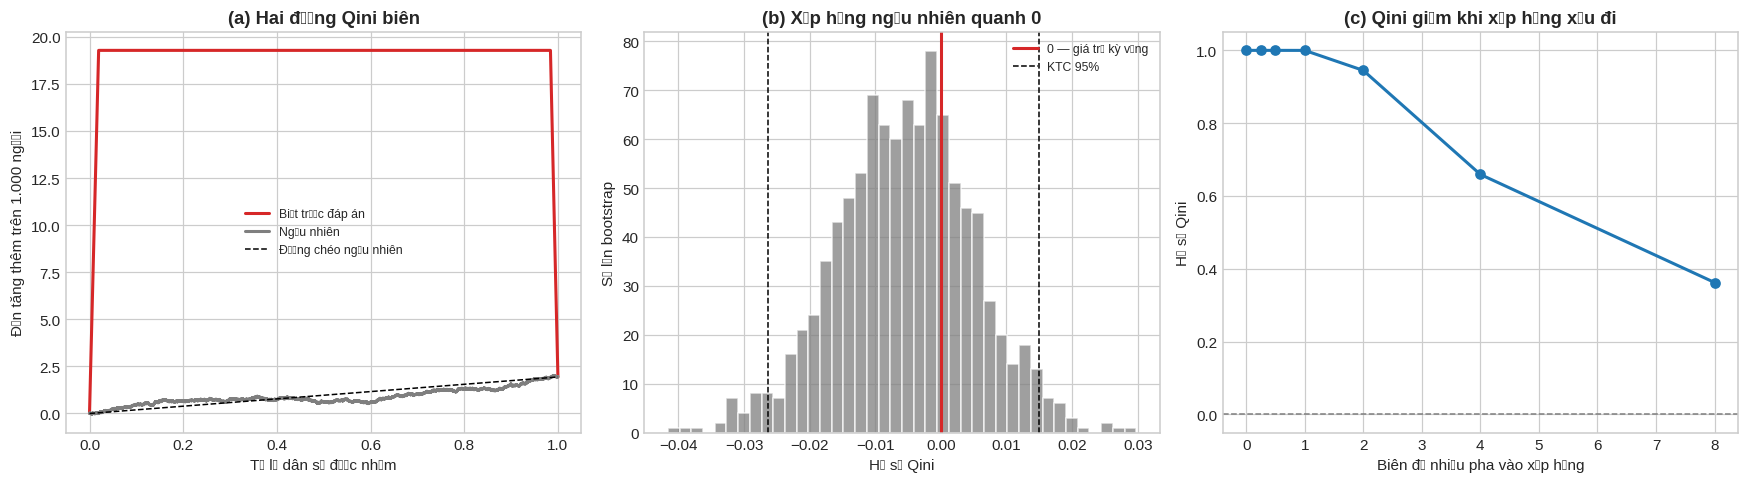

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) ba đường Qini
for s, nhan, mau in [(s_oracle, 'Biết trước đáp án', '#d62728'),
                     (score_ngau_nhien, 'Ngẫu nhiên', '#7f7f7f')]:
    x, g = qini_curve(y_sel, w_sel, s)
    axes[0].plot(x, g * 1000, label=nhan, color=mau, lw=2)
x, g = qini_curve(y_sel, w_sel, s_oracle)
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1, label='Đường chéo ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Hai đường Qini biên')
axes[0].legend(fontsize=8)

# (b) phân phối bootstrap của xếp hạng ngẫu nhiên
_, _, _, vals_rnd = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
axes[1].hist(vals_rnd, bins=40, color='#7f7f7f', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='#d62728', lw=2, label='0 — giá trị kỳ vọng')
axes[1].axvline(lo_rnd, color='black', ls='--', lw=1)
axes[1].axvline(hi_rnd, color='black', ls='--', lw=1, label='KTC 95%')
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_ylabel('Số lần bootstrap')
axes[1].set_title('(b) Xếp hạng ngẫu nhiên quanh 0')
axes[1].legend(fontsize=8)

# (c) suy giảm theo nhiễu
axes[2].plot(bang_nhieu['Biên độ nhiễu'], bang_nhieu['Qini'], 'o-', color='#1f77b4', lw=2)
axes[2].axhline(0, color='#7f7f7f', ls='--', lw=1)
axes[2].set_xlabel('Biên độ nhiễu pha vào xếp hạng')
axes[2].set_ylabel('Hệ số Qini')
axes[2].set_title('(c) Qini giảm khi xếp hạng xấu đi')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '14_kiem_chung_metric.png'), bbox_inches='tight')
plt.show()

### Bước 13 — Chốt cổng

Bốn phép thử phải đạt hết thì mới được đi tiếp. Dùng `assert` chứ không chỉ in ra màn hình, để nếu
sau này ai chạy lại notebook mà metric hỏng thì notebook dừng ngay tại đây thay vì tiếp tục sinh ra
một bảng benchmark sai.

In [17]:
kiem_chung = pd.DataFrame([
    {'Phép thử': '1. Xếp hạng ngẫu nhiên → Qini ≈ 0',
     'Kết quả': fmt_ci(q_rnd, lo_rnd, hi_rnd, 4), 'Đạt': chua_khong},
    {'Phép thử': '2. ATE khớp phép tính tay',
     'Kết quả': f'sai lệch {sai_lech:.1e}', 'Đạt': khop},
    {'Phép thử': '3. Biết trước ≫ ngẫu nhiên',
     'Kết quả': f'{dt_oracle/abs(dt_ngau_nhien):.0f} lần', 'Đạt': cao_hon},
    {'Phép thử': '4. Qini giảm đơn điệu theo nhiễu',
     'Kết quả': f'{bang_nhieu.Qini.iloc[0]:.3f} → {bang_nhieu.Qini.iloc[-1]:.3f}',
     'Đạt': giam_don_dieu},
])

display(kiem_chung)

assert kiem_chung['Đạt'].all(), 'Có phép kiểm chứng không đạt — sửa công thức metric trước khi đi tiếp'
print('\n✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.')

,Phép thử,Kết quả,Đạt
0,1. Xếp hạng ngẫu nhiên → Qini ≈ 0,-0.0051 [-0.0264 – 0.0150],True
1,2. ATE khớp phép tính tay,sai lệch 0.0e+00,True
2,3. Biết trước ≫ ngẫu nhiên,196 lần,True
3,4. Qini giảm đơn điệu theo nhiễu,1.000 → 0.362,True



✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.


---
# Phần 3 — Đấu trên RCT-select

Tập `rct_select` là dữ liệu ngẫu nhiên hóa nên Qini đo trên đó không bị bóp méo bởi thiên vị chọn lọc.
Đây là nơi duy nhất được phép chọn quán quân.

### Bước 14 — Qini và AUUC kèm khoảng tin cậy

Mỗi mô hình chạy bootstrap `N_BOOT` lần cho Qini và ngần ấy lần cho AUUC. Chạy vài phút.

In [18]:
ket_qua_sel = []
boot_sel = {}

for name in OK_MODELS:
    s = cate_sel[name]
    q, q_lo, q_hi, q_vals = bootstrap_ci(qini_score, y_sel, w_sel, s)
    a, a_lo, a_hi, _ = bootstrap_ci(auuc_score, y_sel, w_sel, s)
    boot_sel[name] = q_vals
    ket_qua_sel.append({'Mô hình': name, 'Qini': q, 'Qini_lo': q_lo, 'Qini_hi': q_hi,
                        'AUUC': a, 'AUUC_lo': a_lo, 'AUUC_hi': a_hi,
                        'Uplift@20%': uplift_at_k(y_sel, w_sel, s, 0.2),
                        'Giây huấn luyện': thoi_gian[name],
                        'Dòng huấn luyện': n_dong_fit[name]})
    print(f'{name:<18} Qini = {fmt_ci(q, q_lo, q_hi)} | AUUC = {fmt_ci(a, a_lo, a_hi)}')

# mốc tham chiếu: xếp hạng ngẫu nhiên
ket_qua_sel.append({'Mô hình': '— Ngẫu nhiên (mốc)', 'Qini': q_rnd,
                    'Qini_lo': lo_rnd, 'Qini_hi': hi_rnd,
                    'AUUC': np.nan, 'AUUC_lo': np.nan, 'AUUC_hi': np.nan,
                    'Uplift@20%': uplift_at_k(y_sel, w_sel, score_ngau_nhien, 0.2),
                    'Giây huấn luyện': 0.0, 'Dòng huấn luyện': 0})

df_sel = pd.DataFrame(ket_qua_sel).sort_values('Qini', ascending=False).reset_index(drop=True)

SLearner           Qini = 0.019 [-0.005 – 0.042] | AUUC = 0.020 [-0.006 – 0.045]
TLearner           Qini = 0.016 [-0.009 – 0.042] | AUUC = 0.017 [-0.010 – 0.045]
DRLearner          Qini = 0.027 [0.004 – 0.053] | AUUC = 0.030 [0.004 – 0.058]
LinearDML          Qini = 0.007 [-0.016 – 0.028] | AUUC = 0.007 [-0.017 – 0.030]
NonParamDML        Qini = 0.015 [-0.009 – 0.039] | AUUC = 0.016 [-0.009 – 0.041]
CausalForestDML    Qini = 0.015 [-0.008 – 0.037] | AUUC = 0.017 [-0.008 – 0.041]


### Bước 15 — Bảng xếp hạng

In [19]:
bang_sel = pd.DataFrame({
    'Mô hình': df_sel['Mô hình'],
    'Qini [KTC 95%]': [fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi) for r in df_sel.itertuples()],
    'AUUC [KTC 95%]': [('—' if np.isnan(r.AUUC) else fmt_ci(r.AUUC, r.AUUC_lo, r.AUUC_hi))
                       for r in df_sel.itertuples()],
    'Uplift@20%': (df_sel['Uplift@20%'] * 100).round(3).astype(str) + ' pp',
    'Dòng HL': df_sel['Dòng huấn luyện'].map('{:,}'.format),
    'Giây': df_sel['Giây huấn luyện'].round(1),
})
display(bang_sel)

,Mô hình,Qini [KTC 95%],AUUC [KTC 95%],Uplift@20%,Dòng HL,Giây
0,DRLearner,0.027 [0.004 – 0.053],0.030 [0.004 – 0.058],1.088 pp,"926,669",213.6
1,SLearner,0.019 [-0.005 – 0.042],0.020 [-0.006 – 0.045],0.815 pp,"926,669",11.0
2,TLearner,0.016 [-0.009 – 0.042],0.017 [-0.010 – 0.045],1.06 pp,"926,669",20.8
3,CausalForestDML,0.015 [-0.008 – 0.037],0.017 [-0.008 – 0.041],0.879 pp,"926,669",1861.6
4,NonParamDML,0.015 [-0.009 – 0.039],0.016 [-0.009 – 0.041],1.02 pp,"926,669",86.0
5,LinearDML,0.007 [-0.016 – 0.028],0.007 [-0.017 – 0.030],0.689 pp,"926,669",171.7
6,— Ngẫu nhiên (mốc),-0.005 [-0.026 – 0.015],—,0.623 pp,0,0.0


### Bước 16 — Đường Qini của các mô hình

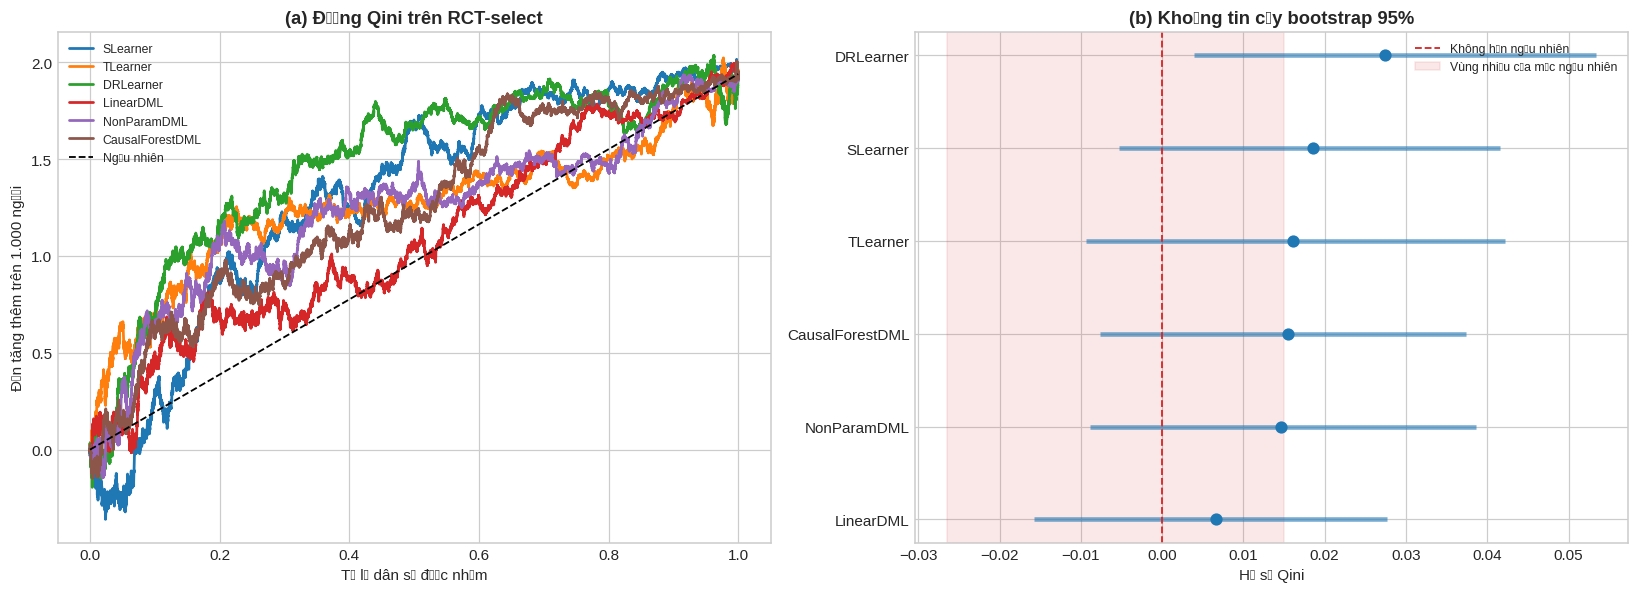

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

mau_sac = plt.cm.tab10(np.linspace(0, 1, 10))

for i, name in enumerate(OK_MODELS):
    x, g = qini_curve(y_sel, w_sel, cate_sel[name])
    axes[0].plot(x, g * 1000, label=name, color=mau_sac[i], lw=1.8)

x, g = qini_curve(y_sel, w_sel, cate_sel[OK_MODELS[0]])
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1.2, label='Ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Đường Qini trên RCT-select')
axes[0].legend(fontsize=8, loc='upper left')

# (b) khoảng tin cậy dạng thanh ngang
dfp = df_sel[df_sel['Mô hình'] != '— Ngẫu nhiên (mốc)'].iloc[::-1]
ypos = np.arange(len(dfp))
axes[1].hlines(ypos, dfp['Qini_lo'], dfp['Qini_hi'], color='#1f77b4', lw=3, alpha=0.6)
axes[1].plot(dfp['Qini'], ypos, 'o', color='#1f77b4', ms=7)
axes[1].axvline(0, color='#d62728', ls='--', lw=1.2, label='Không hơn ngẫu nhiên')
axes[1].axvspan(lo_rnd, hi_rnd, color='#d62728', alpha=0.10, label='Vùng nhiễu của mốc ngẫu nhiên')
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(dfp['Mô hình'])
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_title('(b) Khoảng tin cậy bootstrap 95%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '15_qini_rct_select.png'), bbox_inches='tight')
plt.show()

### Bước 17 — Chọn quán quân, và kiểm tra xem lựa chọn đó có ý nghĩa không

Hai câu hỏi tách bạch, hay bị gộp làm một:

1. *Mô hình nào có Qini điểm cao nhất?* — luôn có câu trả lời, chỉ cần sắp xếp.
2. *Chênh lệch đó có vượt được nhiễu không?* — mới là câu hỏi khoa học.

Kiểm câu thứ hai bằng bootstrap **theo cặp**: trong mỗi lần lấy mẫu lại, tính hiệu Qini của quán quân
trừ Qini của từng đối thủ trên **cùng một mẫu**. Cách này khử được phần dao động chung do mẫu — thứ
tác động lên cả hai mô hình như nhau — nên nhạy hơn nhiều so với việc nhìn xem hai khoảng tin cậy
riêng lẻ có chồng lấn hay không.

**Một hệ quả triển khai cần biết trước.** Quán quân được chọn thuần theo hệ số Qini. Nếu người thắng
là một estimator EconML (`LinearDML`, `NonParamDML`, `CausalForestDML`) thì bản bàn giao **không có
dạng text của LightGBM** — chỉ có `model.pkl`, và file đó phụ thuộc phiên bản Python (xem 04c).
Notebook không tự đổi luật chọn vì chuyện đó; nếu đội triển khai muốn ưu tiên mô hình xuất được ra
định dạng bền vững khi chênh lệch Qini không có ý nghĩa thống kê, đó là một quyết định phải nêu rõ
trong báo cáo chứ không nên giấu vào code.

In [21]:
quan_quan = df_sel[df_sel['Mô hình'] != '— Ngẫu nhiên (mốc)'].iloc[0]['Mô hình']
print(f'Qini điểm cao nhất: {quan_quan}\n')

rng_pair = np.random.RandomState(SEED)
n_sel = len(y_sel)
idx_boot = [rng_pair.randint(0, n_sel, n_sel) for _ in range(N_BOOT)]

so_sanh = []
for name in OK_MODELS:
    if name == quan_quan:
        continue
    hieu = np.array([qini_score(y_sel[i], w_sel[i], cate_sel[quan_quan][i])
                     - qini_score(y_sel[i], w_sel[i], cate_sel[name][i]) for i in idx_boot])
    lo, hi = np.percentile(hieu, [2.5, 97.5])
    so_sanh.append({'Đối thủ': name, 'Chênh lệch Qini': hieu.mean(),
                    'KTC thấp': lo, 'KTC cao': hi,
                    # Hai phía: khoảng tin cậy có tách khỏi 0 không.
                    'KTC khác 0': bool(lo > 0 or hi < 0),
                    # Một phía: chỉ khi CẢ khoảng nằm trên 0 mới là "quán quân hơn".
                    'Quán quân thắng': bool(lo > 0)})

df_ss = pd.DataFrame(so_sanh)
display(df_ss.round(4))

# "Khoảng tin cậy khác 0" là phép thử HAI phía, còn "vượt trội" là một phía. Đếm bằng
# cột hai phía thì một đối thủ MẠNH HƠN cũng bị cộng vào như thắng. Quán quân đang được
# chọn theo điểm Qini cao nhất nên n_thua luôn bằng 0; cảnh báo bên dưới để nếu luật chọn
# đổi (ví dụ ưu tiên mô hình xuất được ra định dạng bền vững) thì lỗi không đi âm thầm.
n_thang = int(df_ss['Quán quân thắng'].sum())
n_thua = int((df_ss['KTC cao'] < 0).sum())

print(f'\n{quan_quan} vượt trội có ý nghĩa thống kê so với {n_thang}/{len(df_ss)} đối thủ.')
if n_thua:
    print(f'>>> BẤT THƯỜNG: {quan_quan} THUA có ý nghĩa {n_thua} đối thủ '
          '— kiểm lại cách chọn quán quân <<<')
if n_thang == 0:
    print('=> Không mô hình nào tách khỏi phần còn lại. Kết luận trung thực: các phương pháp')
    print('   KHÔNG khác biệt có ý nghĩa thống kê trên bộ dữ liệu này.')
    print('   Vẫn lấy mô hình điểm cao nhất làm quán quân để có thứ bàn giao, nhưng phải nói rõ')
    print('   lựa chọn đó nằm trong vùng nhiễu.')

Qini điểm cao nhất: DRLearner



,Đối thủ,Chênh lệch Qini,KTC thấp,KTC cao,KTC khác 0,Quán quân thắng
0,SLearner,0.0098,-0.0182,0.0365,False,False
1,TLearner,0.0116,-0.0149,0.0389,False,False
2,LinearDML,0.0217,-0.0040,0.0490,False,False
3,NonParamDML,0.0143,-0.0111,0.0385,False,False
4,CausalForestDML,0.0131,-0.0122,0.0374,False,False



DRLearner vượt trội có ý nghĩa thống kê so với 0/5 đối thủ.
=> Không mô hình nào tách khỏi phần còn lại. Kết luận trung thực: các phương pháp
   KHÔNG khác biệt có ý nghĩa thống kê trên bộ dữ liệu này.
   Vẫn lấy mô hình điểm cao nhất làm quán quân để có thứ bàn giao, nhưng phải nói rõ
   lựa chọn đó nằm trong vùng nhiễu.


---
# Phần 4 — Độ quan trọng đặc trưng & chọn số đặc trưng

Phần này kết thúc bằng hai quyết định cuối: **giữ lại bao nhiêu đặc trưng** và **bàn giao mô hình nào**.
Xong hai thứ đó thì mọi lựa chọn bị đóng băng, và 04c chỉ còn việc đo.

Điểm mấu chốt: **k không được gõ tay.** Cả vùng quét lẫn giá trị chốt đều suy ra từ dữ liệu — vùng
quét từ đường gain của mô hình, giá trị chốt từ Qini đo trên `rct_select`.

### Bước 18 — Định nghĩa lại 6 mô hình

Chép nguyên từ notebook 03. Các notebook cố tình không import lẫn nhau — mỗi cái phải chạy độc lập
từ trên xuống — nên phải lặp lại phần định nghĩa. Đổi lại, nếu sau này ai chỉ mở notebook 04 thì vẫn
đọc hiểu được toàn bộ mô hình mà không phải mở file khác.

Hai điểm khác notebook 03, cả hai đều có lý do:

- **Ngưỡng cắt propensity không gõ lại.** `compute_dr_scores` mặc định dùng `E_CLIP`, biến mà Bước 3
  vừa đọc từ `best_params.json`. Gõ lại một con số ở đây là mở đường cho việc hai notebook cắt `ê` ở
  hai ngưỡng khác nhau, và khi đó bộ siêu tham số tinh chỉnh cho một mô hình lại đem áp cho một mô
  hình khác. Lưu ý notebook 03 còn **trim** vùng ngoài overlap, nhưng chỉ trim ở phía *thước đo*;
  phía huấn luyện thì cả hai notebook đều chỉ clip, nên phần này khớp nhau.
- **DR-Learner được đặt `importance_type='gain'`.** Mặc định của LightGBM là đếm **số lần** một đặc
  trưng được dùng để chia nhánh, cách đó thiên vị nặng cho đặc trưng liên tục nhiều giá trị vì chúng
  có nhiều điểm cắt để thử. Gần một nửa số cột ở đây là nhị phân, dùng mặc định sẽ đánh giá thấp
  chúng một cách oan uổng. `gain` đo mức giảm hàm mất mát thực tế mà mỗi lần chia mang lại, công bằng
  giữa hai loại.

In [22]:
def compute_dr_scores(X, W, Y, n_folds=5, seed=SEED, clip=None):
    '''Pseudo-outcome doubly robust, ước lượng bằng cross-fitting.
       clip = None nghĩa là dùng E_CLIP đọc từ best_params.json ở Bước 3 — phải đúng
       ngưỡng notebook 03 đã tinh chỉnh, nếu không thì tham số áp cho một mô hình khác.'''
    clip = E_CLIP if clip is None else clip
    n = len(X)
    e_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)

    strata = W * 2 + Y
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

    nuisance_params = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                           min_child_samples=50, random_state=seed, verbose=-1)

    for tr, te in skf.split(X, strata):
        m_e = lgb.LGBMClassifier(**nuisance_params).fit(X[tr], W[tr])
        e_hat[te] = np.clip(m_e.predict_proba(X[te])[:, 1], *clip)

        m0 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 0], Y[tr][W[tr] == 0])
        m1 = lgb.LGBMClassifier(**nuisance_params).fit(X[tr][W[tr] == 1], Y[tr][W[tr] == 1])
        mu0_hat[te] = m0.predict_proba(X[te])[:, 1]
        mu1_hat[te] = m1.predict_proba(X[te])[:, 1]

    dr = ((mu1_hat - mu0_hat)
          + W * (Y - mu1_hat) / e_hat
          - (1 - W) * (Y - mu0_hat) / (1 - e_hat))

    return dr, e_hat, mu0_hat, mu1_hat


class SLearner:
    '''Một mô hình duy nhất trên [X, W]. CATE = f(X,1) - f(X,0).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.model = lgb.LGBMClassifier(**self.params).fit(np.column_stack([X, W]), Y)
        return self

    def predict_cate(self, X):
        n = len(X)
        p1 = self.model.predict_proba(np.column_stack([X, np.ones(n)]))[:, 1]
        p0 = self.model.predict_proba(np.column_stack([X, np.zeros(n)]))[:, 1]
        return p1 - p0


class TLearner:
    '''Hai mô hình riêng cho nhóm treatment và control. CATE = f1(X) - f0(X).'''
    def __init__(self, **params):
        self.params = dict(params, random_state=SEED, verbose=-1)

    def fit(self, X, W, Y):
        self.m1 = lgb.LGBMClassifier(**self.params).fit(X[W == 1], Y[W == 1])
        self.m0 = lgb.LGBMClassifier(**self.params).fit(X[W == 0], Y[W == 0])
        return self

    def predict_cate(self, X):
        return self.m1.predict_proba(X)[:, 1] - self.m0.predict_proba(X)[:, 1]


class DRLearner:
    '''Kennedy 2020 — hồi quy pseudo-outcome doubly robust.'''
    def __init__(self, n_folds=5, **params):
        self.n_folds = n_folds
        self.params = dict(params, random_state=SEED, verbose=-1, importance_type='gain')

    def fit(self, X, W, Y):
        dr_train, *_ = compute_dr_scores(X, W, Y, n_folds=self.n_folds)
        self.model = lgb.LGBMRegressor(**self.params).fit(X, dr_train)
        return self

    def predict_cate(self, X):
        return self.model.predict(X)


class EconMLWrapper:
    '''Bọc estimator của EconML về cùng giao diện fit/predict_cate.'''
    def __init__(self, estimator):
        self.est = estimator

    def fit(self, X, W, Y):
        self.est.fit(Y, W, X=X)
        return self

    def predict_cate(self, X):
        return np.asarray(self.est.effect(X)).ravel()


print('Đã định nghĩa 6 lớp mô hình')

Đã định nghĩa 6 lớp mô hình


### Bước 19 — Hàm dựng mô hình từ tên và tham số

In [23]:
def make_nuisance(p):
    common = dict(n_estimators=p['nuisance_n_estimators'], learning_rate=0.05,
                  max_depth=p['nuisance_max_depth'], random_state=SEED, verbose=-1)
    return lgb.LGBMRegressor(**common), lgb.LGBMClassifier(**common)


def build_model(name, p):
    if name == 'SLearner':
        return SLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'TLearner':
        return TLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                        max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])
    if name == 'DRLearner':
        return DRLearner(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                         max_depth=p['max_depth'], min_child_samples=p['min_child_samples'])

    model_y, model_t = make_nuisance(p)
    if name == 'LinearDML':
        return EconMLWrapper(LinearDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            cv=p['cv'], random_state=SEED))
    if name == 'NonParamDML':
        return EconMLWrapper(NonParamDML(
            model_y=model_y, model_t=model_t,
            model_final=lgb.LGBMRegressor(
                n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                max_depth=p['max_depth'], min_child_samples=p['min_child_samples'],
                random_state=SEED, verbose=-1),
            discrete_treatment=True, cv=p['cv'], random_state=SEED))
    if name == 'CausalForestDML':
        return EconMLWrapper(CausalForestDML(
            model_y=model_y, model_t=model_t, discrete_treatment=True,
            n_estimators=p['cf_n_estimators'], min_samples_leaf=p['cf_min_samples_leaf'],
            max_depth=p['cf_max_depth'], cv=p['cv'], random_state=SEED))

    raise ValueError(f'Không biết mô hình: {name}')


print('Đã định nghĩa build_model')

Đã định nghĩa build_model


Vòng quét ở Bước 23 và bản bàn giao ở Bước 26 đều phải huấn luyện lại mô hình, nên cần sẵn ma trận Train + Val ở đây. `lay_mau` lấy mẫu phân tầng theo `(W, Y)` để mọi cỡ mẫu con vẫn giữ nguyên tỉ lệ bốn tổ hợp.

In [24]:
full = pd.concat([train, val], ignore_index=True)

X_full = full[FEATS].values.astype(np.float32)
W_full = full['is_treat'].values
Y_full = full['label'].values

X_sel = rct_sel[FEATS].values.astype(np.float32)

print(f'Tập huấn luyện gộp : {len(full):,} dòng × {len(FEATS)} đặc trưng')
print(f'  treat {W_full.mean()*100:.2f}% | mua {Y_full.mean()*100:.2f}%')
print(f'  bộ nhớ X: {X_full.nbytes/1e6:.0f} MB')
print(f'Tập RCT-select     : {len(rct_sel):,} dòng')

Tập huấn luyện gộp : 926,669 dòng × 69 đặc trưng
  treat 22.17% | mua 1.99%
  bộ nhớ X: 256 MB
Tập RCT-select     : 90,834 dòng


In [25]:
def lay_mau(n_max, seed=SEED):
    """Lấy mẫu phân tầng theo cặp (W, Y) để giữ nguyên tỉ lệ 4 tổ hợp."""
    if n_max is None or n_max >= len(full):
        return np.arange(len(full))
    strata = W_full * 2 + Y_full
    rng = np.random.RandomState(seed)
    idx = []
    for s in np.unique(strata):
        pos = np.where(strata == s)[0]
        k = max(1, int(round(n_max * len(pos) / len(full))))
        idx.append(rng.choice(pos, size=min(k, len(pos)), replace=False))
    return np.sort(np.concatenate(idx))


print('Đã định nghĩa lay_mau')

Đã định nghĩa lay_mau


### Bước 20 — Độ quan trọng lấy từ tầng cuối của DR-Learner

DR-Learner có cấu trúc thuận tiện cho việc này: tầng cuối của nó là một mô hình hồi quy đơn giản ánh
xạ thẳng từ đặc trưng sang pseudo-outcome doubly robust. Nên độ quan trọng đọc ra ở đó là *đặc trưng
nào quyết định hiệu ứng điều trị*, chứ không phải *đặc trưng nào quyết định việc mua hàng* — hai câu
hỏi hoàn toàn khác nhau, và cái thứ nhất mới là cái đề tài cần.

Đã đặt `importance_type='gain'` ở Bước 18, lý do giải thích ở đó.

Con số cần chú ý nhất ở đây không phải top mấy, mà là **số đặc trưng có gain đúng bằng 0**. Gain
bằng 0 nghĩa là trong toàn bộ cây của tầng cuối, mô hình **chưa từng một lần chia nhánh** theo đặc
trưng đó. Dự đoán của mô hình hoàn toàn không phụ thuộc vào giá trị của chúng — đây là một ngưỡng do
dữ liệu tự vạch ra chứ không do ai chọn, và nó là cận trên tự nhiên cho vùng cần quét ở Bước 22.

In [26]:
if 'DRLearner' in OK_MODELS:
    imp = pd.Series(nap_mo_hinh('DRLearner').model.feature_importances_,
                    index=FEATS).sort_values(ascending=False)
    imp_pct = imp / imp.sum() * 100
    cum_pct = imp_pct.cumsum()
    n_dung = int((imp > 0).sum())

    print('Top 15 đặc trưng theo gain:\n')
    display(pd.DataFrame({'Gain': imp.head(15).round(1),
                          '% tổng gain': imp_pct.head(15).round(2),
                          '% tích lũy': cum_pct.head(15).round(2)}))

    print(f'\nĐặc trưng mô hình THỰC SỰ dùng (gain > 0) : {n_dung}/{len(FEATS)}')
    print(f'Đặc trưng chưa từng được chia nhánh       : {len(FEATS) - n_dung}')
    if quan_quan != 'DRLearner':
        print(f'\nLưu ý: quán quân là {quan_quan}, nhưng độ quan trọng vẫn lấy từ DR-Learner '
              'vì tầng cuối của nó ánh xạ thẳng đặc trưng sang pseudo-outcome.')
else:
    imp, n_dung = None, 0
    print('DR-Learner không huấn luyện được — bỏ qua phần độ quan trọng')

Top 15 đặc trưng theo gain:



,Gain,% tổng gain,% tích lũy
f31,1302.9,9.15,9.15
f30,1069.8,7.51,16.66
f2,710.3,4.99,21.64
f20,638.6,4.48,26.13
f22,516.5,3.63,29.75
f1,507.9,3.57,33.32
f8,492.9,3.46,36.78
f5,472.9,3.32,40.10
f38,459.5,3.23,43.33
f68,423.0,2.97,46.30



Đặc trưng mô hình THỰC SỰ dùng (gain > 0) : 65/69
Đặc trưng chưa từng được chia nhánh       : 4


### Bước 21 — Biểu đồ độ quan trọng và đường gain tích lũy

Panel bên phải là thứ quyết định vùng quét ở bước sau: đường gain tích lũy cho thấy tín hiệu tập
trung vào bao nhiêu đặc trưng đầu, và nó phẳng hẳn ra từ đâu.

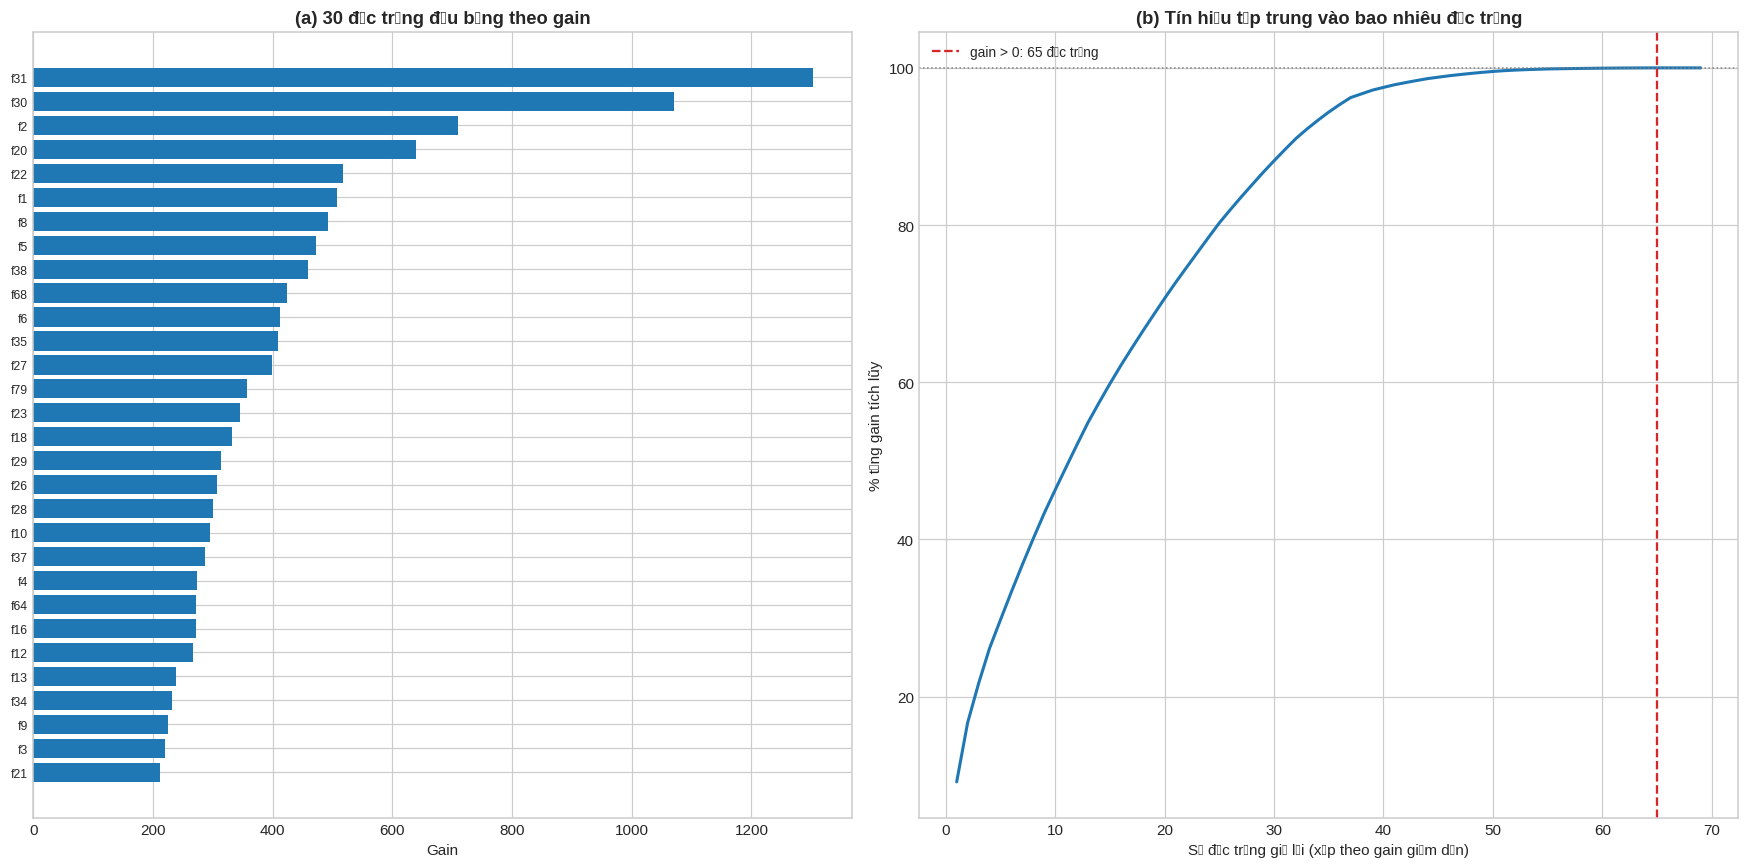

65/69 đặc trưng có gain > 0; 32 đặc trưng đầu đã chiếm 90% tổng gain


In [27]:
if imp is not None:
    n_ve = min(30, n_dung)          # chỉ để nhìn cho vừa khung, không quyết định gì
    top_ve = imp.head(n_ve)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].barh(range(len(top_ve)), top_ve.values, color='#1f77b4')
    axes[0].set_yticks(range(len(top_ve)))
    axes[0].set_yticklabels(top_ve.index, fontsize=8)
    axes[0].set_xlabel('Gain')
    axes[0].set_title(f'(a) {n_ve} đặc trưng đầu bảng theo gain')

    axes[1].plot(range(1, len(imp) + 1), cum_pct.values, '-', color='#1f77b4', lw=2)
    axes[1].axvline(n_dung, color='#d62728', ls='--', lw=1.5,
                    label=f'gain > 0: {n_dung} đặc trưng')
    axes[1].axhline(100, color='#7f7f7f', ls=':', lw=1)
    axes[1].set_xlabel('Số đặc trưng giữ lại (xếp theo gain giảm dần)')
    axes[1].set_ylabel('% tổng gain tích lũy')
    axes[1].set_title('(b) Tín hiệu tập trung vào bao nhiêu đặc trưng')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, '16_do_quan_trong_dac_trung.png'), bbox_inches='tight')
    plt.show()

    print(f'{n_dung}/{N_FEAT} đặc trưng có gain > 0; '
          f'{int((cum_pct <= 90).sum()) + 1} đặc trưng đầu đã chiếm 90% tổng gain')

### Bước 22 — Permutation importance: đo trực tiếp trên thước đo cuối

Gain ở Bước 20 có hai giới hạn phải nói thẳng:

- Nó chỉ tồn tại với mô hình LightGBM, mà quán quân có thể là một estimator EconML.
- Nó đo mức giảm **hàm mất mát của tầng cuối** trên dữ liệu huấn luyện, không phải mức đóng góp vào
  thứ ta thật sự quan tâm là **hệ số Qini trên tập RCT**.

Permutation importance không dính hai giới hạn đó: xáo ngẫu nhiên một cột rồi đo Qini tụt bao nhiêu.
Mô hình giữ nguyên, chỉ mối liên hệ giữa cột đó và nhãn bị phá. Cột nào xáo mà Qini không đổi thì mô
hình không dùng tới nó theo cách có ích.

Ba điều phải nhớ khi đọc bảng này:

- **Đo trên `rct_select`**, đúng tập được phép dùng để ra quyết định. Không đụng tới holdout.
- **Xáo `N_PERM_REPEAT` lần mỗi cột** rồi lấy trung bình, vì một lần xáo lẻ có dao động riêng của nó.
- Cột tương quan cao với nhau sẽ **chia nhau** phần quan trọng: xáo một cột trong cặp thì cột kia vẫn
  gánh được thông tin, nên cả hai cùng bị đánh giá thấp. Đây là hạn chế cố hữu của phương pháp, và là
  lý do vòng quét ở Bước 23 vẫn phải huấn luyện lại thật chứ không tin thẳng vào bảng xếp hạng này.

In [28]:
def permutation_importance_qini(model, X, y, w, feats, n_repeat=N_PERM_REPEAT,
                                n_rows=N_PERM_ROWS, seed=SEED):
    '''Mức tụt của hệ số Qini khi xáo ngẫu nhiên từng cột. Càng tụt nhiều càng quan trọng.'''
    rng = np.random.RandomState(seed)
    if n_rows is not None and n_rows < len(y):
        lay = rng.choice(len(y), n_rows, replace=False)
        X, y, w = X[lay], y[lay], w[lay]

    q_goc = qini_score(y, w, model.predict_cate(X))
    ket = []
    for j, f in enumerate(feats):
        tut = []
        for _ in range(n_repeat):
            Xp = X.copy()
            Xp[:, j] = X[rng.permutation(len(X)), j]
            tut.append(q_goc - qini_score(y, w, model.predict_cate(Xp)))
        ket.append({'dac_trung': f, 'giam_qini': float(np.mean(tut)),
                    'do_lech_chuan': float(np.std(tut))})

    bang = (pd.DataFrame(ket)
              .sort_values('giam_qini', ascending=False)
              .reset_index(drop=True))
    return float(q_goc), bang


t0 = time.time()
q_goc_perm, perm_imp = permutation_importance_qini(
    nap_mo_hinh(quan_quan), X_sel, y_sel, w_sel, FEATS)
print(f'Xong sau {time.time()-t0:.0f} giây — '
      f'{len(FEATS)} đặc trưng × {N_PERM_REPEAT} lần xáo trên mô hình {quan_quan}\n')

perm_imp['hang'] = np.arange(1, len(perm_imp) + 1)
so_huu_ich = int((perm_imp['giam_qini'] > 0).sum())

print(f'Qini gốc dùng làm mốc          : {q_goc_perm:.5f}')
print(f'Đặc trưng làm Qini tụt khi xáo : {so_huu_ich}/{N_FEAT}')
print(f'Đặc trưng xáo mà Qini không tụt: {N_FEAT - so_huu_ich}\n')
display(perm_imp.head(15).round(6))

Xong sau 174 giây — 69 đặc trưng × 5 lần xáo trên mô hình DRLearner

Qini gốc dùng làm mốc          : 0.02744
Đặc trưng làm Qini tụt khi xáo : 47/69
Đặc trưng xáo mà Qini không tụt: 22



,dac_trung,giam_qini,do_lech_chuan,hang
0,f23,0.019123,0.005951,1
1,f17,0.015418,0.004127,2
2,f22,0.012249,0.004417,3
3,f79,0.012130,0.002423,4
4,f13,0.012000,0.008804,5
5,f38,0.010528,0.001355,6
6,f12,0.009969,0.003265,7
7,f0,0.008105,0.004137,8
8,f31,0.007819,0.006733,9
9,f35,0.007812,0.005064,10


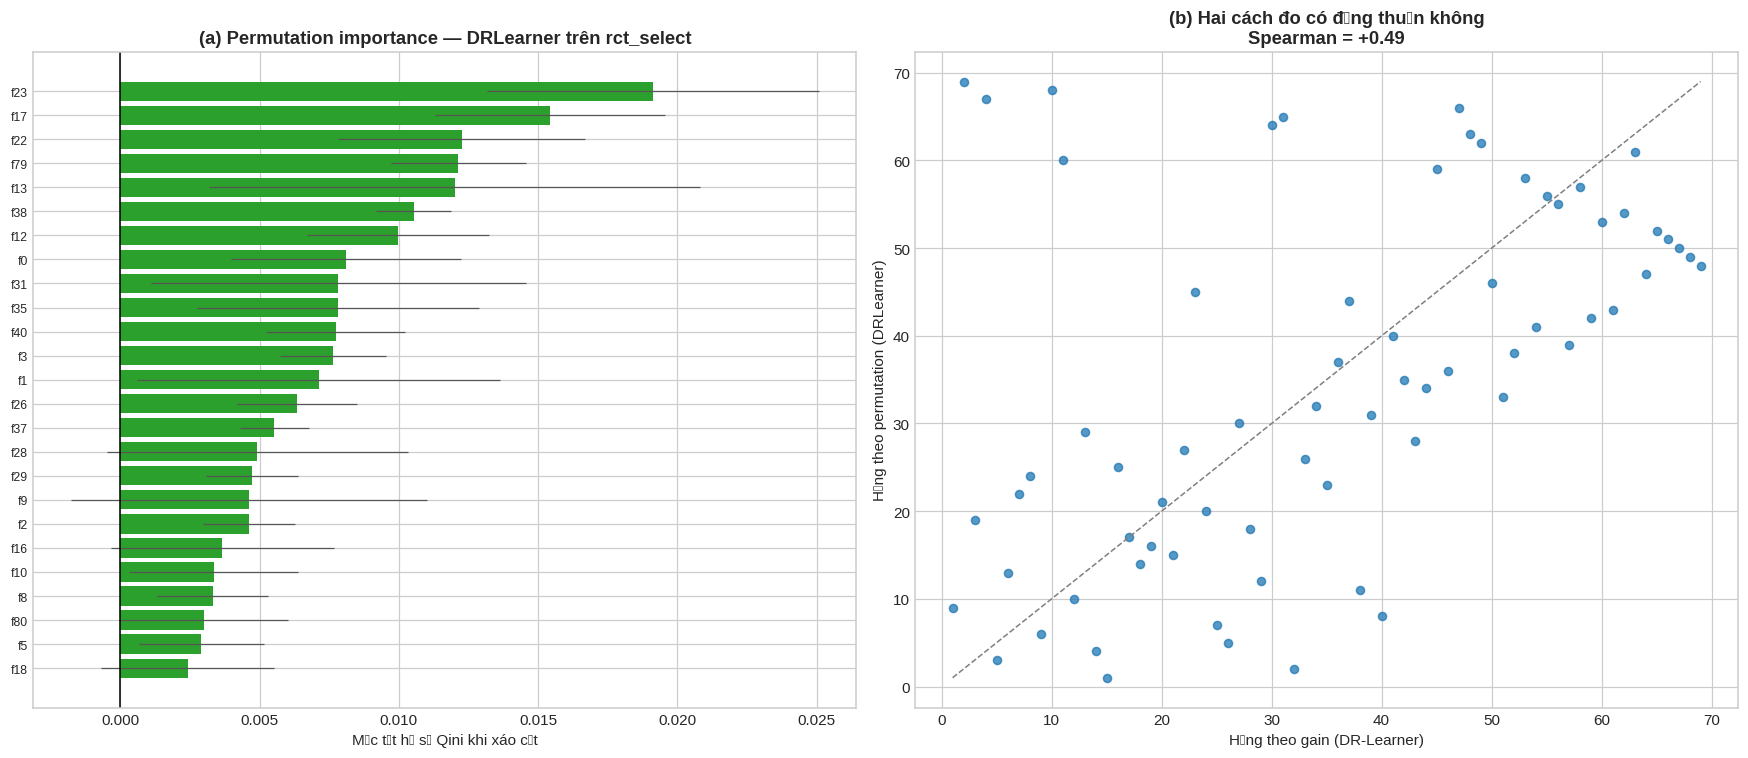

Tương quan hạng giữa gain và permutation importance: +0.49
Hai phép đo độc lập: gain nhìn vào dữ liệu huấn luyện, permutation nhìn vào Qini trên RCT.
Đồng thuận cao thì bảng xếp hạng đáng tin hơn; đồng thuận thấp là dấu hiệu tín hiệu yếu.


In [29]:
top_perm = perm_imp.head(min(25, so_huu_ich if so_huu_ich else 25))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_perm)), top_perm['giam_qini'].values,
             xerr=top_perm['do_lech_chuan'].values, color='#2ca02c',
             error_kw={'lw': 0.8, 'ecolor': '#555555'})
axes[0].axvline(0, color='black', lw=1)
axes[0].set_yticks(range(len(top_perm)))
axes[0].set_yticklabels(top_perm['dac_trung'], fontsize=8)
axes[0].set_xlabel('Mức tụt hệ số Qini khi xáo cột')
axes[0].set_title(f'(a) Permutation importance — {quan_quan} trên rct_select')

if imp is not None:
    hang_gain = pd.Series(np.arange(1, len(imp) + 1), index=imp.index)
    hang_perm = pd.Series(perm_imp['hang'].values, index=perm_imp['dac_trung'])
    chung = hang_gain.index.intersection(hang_perm.index)
    rho_imp, _ = stats.spearmanr(hang_gain[chung], hang_perm[chung])
    axes[1].scatter(hang_gain[chung], hang_perm[chung], s=28, color='#1f77b4', alpha=0.75)
    axes[1].plot([1, N_FEAT], [1, N_FEAT], '--', color='#7f7f7f', lw=1)
    axes[1].set_xlabel('Hạng theo gain (DR-Learner)')
    axes[1].set_ylabel(f'Hạng theo permutation ({quan_quan})')
    axes[1].set_title(f'(b) Hai cách đo có đồng thuận không\nSpearman = {rho_imp:+.2f}')
else:
    rho_imp = np.nan
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '16b_permutation_importance.png'), bbox_inches='tight')
plt.show()

if np.isfinite(rho_imp):
    print(f'Tương quan hạng giữa gain và permutation importance: {rho_imp:+.2f}')
    print('Hai phép đo độc lập: gain nhìn vào dữ liệu huấn luyện, permutation nhìn vào Qini trên RCT.')
    print('Đồng thuận cao thì bảng xếp hạng đáng tin hơn; đồng thuận thấp là dấu hiệu tín hiệu yếu.')

### Bước 23 — Quét k: bỏ bớt đặc trưng tới đâu thì mô hình còn tốt?

Câu hỏi đặt cho đúng là *"giữ lại bao nhiêu đặc trưng thì mô hình vẫn còn tốt"*, và **k phải do dữ liệu trả lời**, không phải do ai gõ vào.

**Mỗi mức k là một mô hình huấn luyện lại từ đầu trên đúng k cột đó** — cùng loại mô hình quán quân, cùng siêu tham số, cùng cỡ mẫu `N_FIT_QUET`.

**Lưới quét dựng từ chính bảng permutation importance**, không có giá trị nào gõ tay:

- Thứ tự bỏ cột: theo mức tụt Qini khi xáo, giảm dần.
- Cận trên: số đặc trưng có mức tụt dương — vượt qua mốc này là thêm những cột xáo đi Qini cũng không giảm.
- Cận dưới: k nhỏ nhất giữ được 50% tổng mức tụt.
- Ở giữa chia đều, cộng thêm mốc đầy đủ `k = 69`.

**Cắt cột thì giữ nguyên thứ tự `FEATS` gốc**, không xếp lại theo độ quan trọng. Nghe như tiểu tiết nhưng không phải: LightGBM khi gặp hai điểm chia ngang tài sẽ lấy đặc trưng đứng trước trong danh sách, mà nhãn DR-score nhiễu nặng nên thế ngang tài xảy ra liên tục. Xếp lại cột — một hoán vị chẳng mang thông tin gì — cũng đủ làm mô hình khác đi.

Hai điều cần nói trước:

- **Vì sao đo trên `rct_select` chứ không phải holdout.** Đây là bước *ra quyết định*. Đo nó trên holdout rồi chọn theo kết quả thì đúng bằng dùng holdout làm tập validation, và toàn bộ con số ở 04c mất giá trị. Notebook này thậm chí không nạp file holdout.
- **Siêu tham số giữ nguyên** bộ đã tinh chỉnh cho 69 đặc trưng. Tinh chỉnh lại cho từng k thì công bằng hơn nhưng tốn gấp nhiều lần, và bản thân việc đó cũng là một dạng chọn lọc trên `rct_select`. Ghi nhận đây là một giới hạn: bản rút gọn có thể đang bị thiệt đôi chút.

In [30]:
# --- lưới k dựng từ bảng permutation importance, không gõ tay giá trị nào ---
XEP_HANG = perm_imp['dac_trung'].tolist()          # quan trọng nhất đứng đầu

duong = perm_imp[perm_imp['giam_qini'] > 0]
k_tren = max(int(len(duong)), 5)
if len(duong):
    cum_perm = duong['giam_qini'].cumsum() / duong['giam_qini'].sum()
    k_min = int((cum_perm < 0.5).sum() + 1)
else:
    k_min = max(1, k_tren // 2)

K_GRID = sorted(set(np.linspace(k_min, k_tren, N_K_GRID).round().astype(int).tolist()
                    + [N_FEAT]))

idx_quet = lay_mau(N_FIT_QUET)

print(f'Cận dưới (giữ 50% tổng mức tụt Qini): {k_min}')
print(f'Cận trên (mức tụt còn dương)        : {k_tren}')
print(f'Lưới quét                           : {K_GRID}')
print(f'Mỗi mức huấn luyện lại {quan_quan} trên {len(idx_quet):,} dòng\n')

cate_theo_k, mo_hinh_theo_k, giay_theo_k = {}, {}, {}
for k in K_GRID:
    # Chọn TẬP k đặc trưng theo độ quan trọng, nhưng giữ nguyên THỨ TỰ cột của FEATS.
    giu = set(XEP_HANG[:k])
    fk = [f for f in FEATS if f in giu]
    ik = [FEATS.index(f) for f in fk]

    t0 = time.time()
    m_k = build_model(quan_quan, BEST[quan_quan]['params']).fit(
        X_full[np.ix_(idx_quet, ik)], W_full[idx_quet], Y_full[idx_quet])
    c_k = m_k.predict_cate(X_sel[:, ik])
    giay_theo_k[k] = time.time() - t0

    if k == N_FEAT:
        assert fk == FEATS, 'Mốc đầy đủ phải giữ nguyên thứ tự cột gốc'

    cate_theo_k[k], mo_hinh_theo_k[k] = c_k, m_k
    print(f'  k = {k:>3} | huấn luyện {giay_theo_k[k]:>5.0f}s | '
          f'CATE trung bình {c_k.mean():+.5f}')

print('\nĐã huấn luyện xong mọi mức k.')

Cận dưới (giữ 50% tổng mức tụt Qini): 9
Cận trên (mức tụt còn dương)        : 47
Lưới quét                           : [9, 18, 28, 38, 47, 69]
Mỗi mức huấn luyện lại DRLearner trên 200,000 dòng

  k =   9 | huấn luyện    25s | CATE trung bình +0.02601
  k =  18 | huấn luyện    32s | CATE trung bình +0.01320
  k =  28 | huấn luyện    39s | CATE trung bình +0.01078
  k =  38 | huấn luyện    41s | CATE trung bình +0.01151
  k =  47 | huấn luyện    45s | CATE trung bình +0.01020
  k =  69 | huấn luyện    67s | CATE trung bình +0.00961

Đã huấn luyện xong mọi mức k.


Giờ mới chấm điểm. Mốc so sánh là `k = 69` của **chính vòng quét này**, để phép so chỉ khác nhau ở số đặc trưng chứ không khác ở cỡ mẫu.

In [31]:
cate_base = cate_theo_k[N_FEAT]
q_base_boot = np.array([qini_score(y_sel[i], w_sel[i], cate_base[i]) for i in idx_boot])

# Kiểm chéo: nếu vòng quét tình cờ dùng đúng cỡ mẫu mà 04a đã dùng cho quán quân thì
# mốc đầy đủ PHẢI trùng khít mô hình của 04a. Lệch nghĩa là cột bị xếp lại ở đâu đó.
cung_co_mau_quet = (len(idx_quet) == n_dong_fit[quan_quan])
if cung_co_mau_quet:
    lech = float(np.abs(cate_base - cate_sel[quan_quan]).max())
    assert lech < 1e-9, (f'Mốc k={N_FEAT} lệch {lech:.2e} so với mô hình 04a '
                         '— kiểm tra lại thứ tự cột')
    print(f'Mốc đầy đủ trùng khít mô hình 04a (lệch {lech:.1e}) — thứ tự cột đúng.')
else:
    print(f'Vòng quét chạy trên {len(idx_quet):,} dòng, 04a huấn luyện quán quân trên '
          f'{n_dong_fit[quan_quan]:,} dòng.')
    print('=> Mốc so sánh là k = 69 của chính vòng quét, không phải mô hình 04a.')
print()

quet = []
for k in K_GRID:
    q, lo, hi, _ = bootstrap_ci(qini_score, y_sel, w_sel, cate_theo_k[k])
    hieu = q_base_boot - np.array([qini_score(y_sel[i], w_sel[i], cate_theo_k[k][i])
                                   for i in idx_boot])
    h_lo, h_hi = np.percentile(hieu, [2.5, 97.5])
    quet.append({'k': k, 'Qini': q, 'Qini_lo': lo, 'Qini_hi': hi,
                 'Hiệu so với đầy đủ': hieu.mean(), 'Hiệu_lo': h_lo, 'Hiệu_hi': h_hi,
                 'Giây': giay_theo_k[k]})
    print(f'  k = {k:>3} | Qini = {fmt_ci(q, lo, hi)} | '
          f'hiệu so với đầy đủ = {hieu.mean():+.4f} [{h_lo:+.4f} – {h_hi:+.4f}]')

df_quet = pd.DataFrame(quet)

Vòng quét chạy trên 200,000 dòng, 04a huấn luyện quán quân trên 926,669 dòng.
=> Mốc so sánh là k = 69 của chính vòng quét, không phải mô hình 04a.

  k =   9 | Qini = -0.000 [-0.023 – 0.024] | hiệu so với đầy đủ = +0.0318 [+0.0030 – +0.0584]
  k =  18 | Qini = 0.004 [-0.021 – 0.029] | hiệu so với đầy đủ = +0.0270 [+0.0020 – +0.0504]
  k =  28 | Qini = 0.016 [-0.010 – 0.041] | hiệu so với đầy đủ = +0.0151 [-0.0063 – +0.0382]
  k =  38 | Qini = 0.014 [-0.010 – 0.038] | hiệu so với đầy đủ = +0.0171 [-0.0058 – +0.0393]
  k =  47 | Qini = 0.018 [-0.005 – 0.043] | hiệu so với đầy đủ = +0.0128 [-0.0086 – +0.0338]
  k =  69 | Qini = 0.031 [0.006 – 0.055] | hiệu so với đầy đủ = +0.0000 [+0.0000 – +0.0000]


### Bước 24 — Quy tắc chốt k

Ba điều kiện, tất cả đo trên `rct_select`. **k chốt là giá trị nhỏ nhất thỏa mãn cả ba.**

| Điều kiện | Ý nghĩa | Cách kiểm |
|---|---|---|
| **1. Còn hơn ngẫu nhiên** | Bản rút gọn vẫn giữ được thứ khiến mô hình đáng báo cáo | KTC Qini không chứa 0 |
| **2. Bền** | Điều kiện 1 đúng ở k này **và ở mọi k lớn hơn** trong lưới | không mức nào phía trên rơi lại |
| **3. Không tệ hơn bản đầy đủ** | Cú cắt không gây thiệt hại đo được | KTC của hiệu chứa 0 |

Điều kiện 1 là chỗ dễ làm thiếu. Chỉ hỏi *"cú giảm có ý nghĩa không"* thì với khoảng tin cậy rộng thế
này hầu như cú giảm nào cũng "không có ý nghĩa", kể cả cú giảm làm mô hình rơi xuống ngang mức ngẫu nhiên.

Điều kiện 2 khó thấy hơn. Đường Qini theo k rất nhiễu — mỗi điểm là một mô hình huấn luyện lại, khoảng
tin cậy chồng lên nhau. Trên một đường như vậy, **lấy k nhỏ nhất vượt ngưỡng chính là đi chọn đúng cái
đỉnh nhiễu thấp nhất**: một mức k tình cờ nhô lên trong khi các mức lân cận cao hơn lại trượt. Đó
không phải tín hiệu, và bàn giao nó cho DE là bàn giao một sự may mắn. Yêu cầu tính bền buộc phải thấy
một *vùng* ổn định thay vì một *điểm* đẹp.

Nếu không k nào thỏa mãn cả ba thì kết luận là **không cắt được** — giữ nguyên toàn bộ 69 đặc trưng. Đó
cũng là một câu trả lời hợp lệ, tốt hơn nhiều so với cắt bừa rồi bàn giao một mô hình đã mất tín hiệu.

In [32]:
df_quet = df_quet.sort_values('k').reset_index(drop=True)
df_quet['Hơn ngẫu nhiên'] = df_quet['Qini_lo'] > 0
# bền: điều kiện 1 đúng ở k này VÀ ở mọi k lớn hơn — quét ngược từ cuối lên
df_quet['Bền'] = df_quet['Hơn ngẫu nhiên'][::-1].cummin()[::-1].astype(bool)
df_quet['Không tệ hơn bản đầy đủ'] = df_quet['Hiệu_lo'] <= 0
df_quet['Đạt'] = df_quet['Bền'] & df_quet['Không tệ hơn bản đầy đủ']

hien = df_quet[['k', 'Qini', 'Qini_lo', 'Qini_hi', 'Hiệu so với đầy đủ',
                'Hơn ngẫu nhiên', 'Bền', 'Không tệ hơn bản đầy đủ', 'Đạt', 'Giây']].copy()
hien['Giây'] = hien['Giây'].round(0)
display(hien.round(4))

dat = df_quet[df_quet['Đạt']]
if len(dat):
    K_CHOT = int(dat['k'].min())
    ly_do = 'k nhỏ nhất thỏa mãn cả ba điều kiện (có tính bền)'
else:
    K_CHOT = N_FEAT
    ly_do = 'không k nào thỏa mãn cả ba điều kiện — giữ nguyên toàn bộ đặc trưng'

roi_lai = df_quet[df_quet['Hơn ngẫu nhiên'] & ~df_quet['Bền']]['k'].tolist()
if roi_lai:
    print(f'Bị loại vì không bền (có mức k lớn hơn rơi lại dưới ngưỡng): {roi_lai}')

r = df_quet[df_quet['k'] == K_CHOT].iloc[0]
print(f'\n=> k chốt: {K_CHOT}  ({ly_do})')
print(f'   Qini = {fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi)}')
print(f'   Bỏ đi {N_FEAT - K_CHOT}/{N_FEAT} đặc trưng')

# FEAT_CHOT luôn theo thứ tự FEATS gốc, khớp đúng cách mô hình được huấn luyện
giu = set(XEP_HANG[:K_CHOT])
FEAT_CHOT = [f for f in FEATS if f in giu]
IDX_CHOT = [FEATS.index(f) for f in FEAT_CHOT]

assert len(FEAT_CHOT) == K_CHOT
assert not any(f.startswith('fe_') for f in FEAT_CHOT)

,k,Qini,Qini_lo,Qini_hi,Hiệu so với đầy đủ,Hơn ngẫu nhiên,Bền,Không tệ hơn bản đầy đủ,Đạt,Giây
0,9,-0.0004,-0.0235,0.0244,0.0318,False,False,False,False,25.0
1,18,0.0040,-0.0210,0.0286,0.0270,False,False,False,False,32.0
2,28,0.0156,-0.0097,0.0410,0.0151,False,False,True,False,39.0
3,38,0.0137,-0.0103,0.0381,0.0171,False,False,True,False,41.0
4,47,0.0180,-0.0051,0.0431,0.0128,False,False,True,False,45.0
5,69,0.0308,0.0064,0.0552,0.0000,True,True,True,True,67.0



=> k chốt: 69  (k nhỏ nhất thỏa mãn cả ba điều kiện (có tính bền))
   Qini = 0.031 [0.006 – 0.055]
   Bỏ đi 0/69 đặc trưng


### Bước 25 — Biểu đồ Qini theo k

Đường này là bằng chứng trực quan cho quyết định vừa rồi: Qini bám ngang khi cắt bớt đặc trưng thừa,
rồi tụt xuống vùng nhiễu khi cắt vào phần mang tín hiệu. Điểm gãy nằm ở đâu là do dữ liệu, không do
ai chọn.

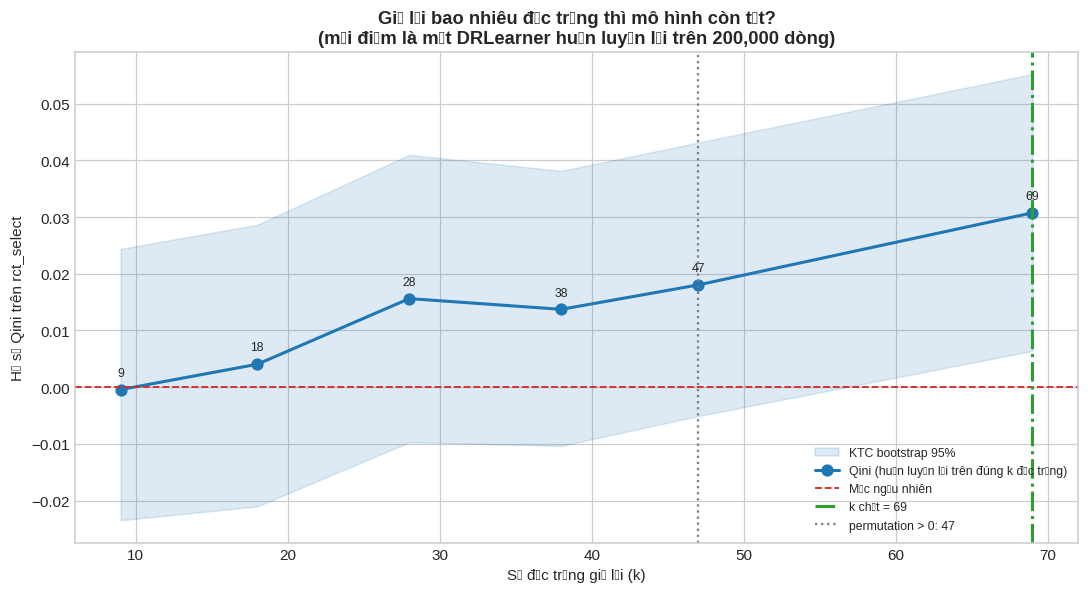

In [33]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.fill_between(df_quet['k'], df_quet['Qini_lo'], df_quet['Qini_hi'],
                color='#1f77b4', alpha=0.15, label='KTC bootstrap 95%')
ax.plot(df_quet['k'], df_quet['Qini'], 'o-', color='#1f77b4', lw=2, ms=7,
        label='Qini (huấn luyện lại trên đúng k đặc trưng)')
ax.axhline(0, color='#d62728', ls='--', lw=1.2, label='Mức ngẫu nhiên')
ax.axvline(K_CHOT, color='#2ca02c', ls='-.', lw=2, label=f'k chốt = {K_CHOT}')
ax.axvline(k_tren, color='#7f7f7f', ls=':', lw=1.5,
           label=f'permutation > 0: {k_tren}')

for _, r in df_quet.iterrows():
    ax.annotate(f'{int(r.k)}', (r.k, r.Qini), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8)

ax.set_xlabel('Số đặc trưng giữ lại (k)')
ax.set_ylabel('Hệ số Qini trên rct_select')
ax.set_title(f'Giữ lại bao nhiêu đặc trưng thì mô hình còn tốt?\n(mỗi điểm là một {quan_quan} huấn luyện lại trên {len(idx_quet):,} dòng)')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '20_quet_so_dac_trung.png'), bbox_inches='tight')
plt.show()

### Bước 26 — Mô hình sẽ bàn giao

Vòng quét trả lời câu hỏi *"giữ bao nhiêu đặc trưng"* ở cỡ mẫu `N_FIT_QUET`. Nhưng bản đem bàn giao thì không có lý do gì phải chịu giới hạn đó — càng nhiều dữ liệu càng tốt, và ở đây không cần công bằng với mô hình nào cả.

Nên:

- Nếu `k = 69`: bàn giao thẳng mô hình quán quân của 04a, vốn đã học trên cỡ mẫu đầy đủ.
- Nếu `k < 69`: huấn luyện lại **một lần** trên đúng `FEAT_CHOT`, với cỡ mẫu mà 04a đã dùng.

Hai câu hỏi khác nhau, hai cỡ mẫu khác nhau, và nói rõ ra thay vì trộn.

In [34]:
if K_CHOT == N_FEAT:
    MO_HINH_GIAO = nap_mo_hinh(quan_quan)
    nguon_giao = f'mô hình của 04a ({n_dong_fit[quan_quan]:,} dòng, toàn bộ đặc trưng)'
    giay_giao = float(thoi_gian[quan_quan])
else:
    n_giao = None if n_dong_fit[quan_quan] >= len(full) else n_dong_fit[quan_quan]
    idx_giao = lay_mau(n_giao)
    t0 = time.time()
    MO_HINH_GIAO = build_model(quan_quan, BEST[quan_quan]['params']).fit(
        X_full[np.ix_(idx_giao, IDX_CHOT)], W_full[idx_giao], Y_full[idx_giao])
    giay_giao = time.time() - t0
    nguon_giao = (f'huấn luyện lại trên {len(idx_giao):,} dòng với {K_CHOT} đặc trưng '
                  f'({giay_giao:.0f}s)')

CATE_GIAO_SEL = MO_HINH_GIAO.predict_cate(X_sel[:, IDX_CHOT])
q_giao, lo_giao, hi_giao, _ = bootstrap_ci(qini_score, y_sel, w_sel, CATE_GIAO_SEL)

print(f'Mô hình bàn giao : {quan_quan} trên {K_CHOT}/{N_FEAT} đặc trưng')
print(f'  Nguồn          : {nguon_giao}')
print(f'  Qini trên rct_select: {fmt_ci(q_giao, lo_giao, hi_giao)}')
print()
print('Con số Qini này đo trên chính tập đã dùng để chọn k nên lạc quan hơn thực tế.')
print('Con số sạch là của 04c, đo trên rct_holdout.')

Mô hình bàn giao : DRLearner trên 69/69 đặc trưng
  Nguồn          : mô hình của 04a (926,669 dòng, toàn bộ đặc trưng)
  Qini trên rct_select: 0.027 [0.004 – 0.053]

Con số Qini này đo trên chính tập đã dùng để chọn k nên lạc quan hơn thực tế.
Con số sạch là của 04c, đo trên rct_holdout.


### Bước 27 — Khóa mọi quyết định trước khi mở holdout

Đây là ô lệnh cuối cùng trước ranh giới. Nó gói toàn bộ những gì đã được *chọn* — mô hình quán quân,
siêu tham số, tập đặc trưng bàn giao — vào một file kèm mã băm, rồi in mã băm đó ra.

Phần 7 tính lại mã băm này trước khi xuất mô hình. Nếu ai đó nhìn kết quả holdout rồi quay lại đổi
quán quân hay đổi k, hai mã băm sẽ khác nhau và notebook dừng ngay tại chỗ. Không có cơ chế này thì
nguyên tắc "holdout chạy một lần" chỉ là một câu nhắc trong markdown.

In [35]:
def goi_quyet_dinh():
    '''Gói mọi thứ đã được CHỌN vào một dict.

    Phần 7 gọi lại đúng hàm này rồi so mã băm: nếu có ai nhìn kết quả holdout xong
    quay lại đổi quán quân hoặc đổi k thì hai mã băm khác nhau và notebook dừng.'''
    return {
        'quan_quan': quan_quan,
        'sieu_tham_so': BEST[quan_quan]['params'],
        'k_chot': int(K_CHOT),
        'dac_trung_ban_giao': FEAT_CHOT,
        'tap_dung_de_quyet_dinh': 'rct_select',
        'cach_chon_quan_quan': 'hệ số Qini trên rct_select, bootstrap theo cặp',
        'cach_chon_k': ly_do,
        'xep_hang_dac_trung': ('permutation importance trên rct_select, '
                               'mỗi mức k huấn luyện lại mô hình trên đúng tập đặc trưng đó'),
        'run_mode': RUN_MODE,
        'seed': SEED,
        'run_id_04a': RUN_ID_04A,
    }


QUYET_DINH = goi_quyet_dinh()
KHOA_HASH = hashlib.sha256(
    json.dumps(QUYET_DINH, ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()[:16]

lock_path = os.path.join(ART_DIR, 'decisions_locked.json')
with open(lock_path, 'w', encoding='utf-8') as f:
    json.dump({**QUYET_DINH,
               'thoi_diem_khoa': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
               'ma_bam': KHOA_HASH}, f, ensure_ascii=False, indent=2)

print('🔒 ĐÃ KHÓA QUYẾT ĐỊNH')
print(f'   Quán quân         : {quan_quan}')
print(f'   Đặc trưng bàn giao: {K_CHOT}/{N_FEAT}')
print(f'   Mã băm            : {KHOA_HASH}')
print(f'   Ghi ra            : {lock_path}')
print('\nTừ đây trở đi chỉ còn đo và báo cáo. Phần 7 sẽ đối chiếu lại mã băm này.')

🔒 ĐÃ KHÓA QUYẾT ĐỊNH
   Quán quân         : DRLearner
   Đặc trưng bàn giao: 69/69
   Mã băm            : 3960fbe51566cb1a
   Ghi ra            : /kaggle/working/artifacts/decisions_locked.json

Từ đây trở đi chỉ còn đo và báo cáo. Phần 7 sẽ đối chiếu lại mã băm này.


### Bước 28 — Ghi bàn giao cho 04c

`decisions_locked.json` ở trên là bản khóa. Ô lệnh này ghi thêm hai thứ 04c cần: **đúng mô hình sẽ bàn giao**, và toàn bộ số liệu đã tính ở notebook này để 04c dựng `metadata.json` mà không phải tính lại.

In [36]:
# --- mô hình bàn giao ---
giao_path = os.path.join(ART_DIR, '04b_model_ban_giao.pkl')
with open(giao_path, 'wb') as f:
    cloudpickle.dump(MO_HINH_GIAO, f)

# --- số liệu cho 04c ---
select_meta = {
    'run_id_04a': RUN_ID_04A,
    'run_id_04b': f"{RUN_MODE}-{datetime.now():%Y%m%d-%H%M%S}-{uuid.uuid4().hex[:6]}",
    'run_mode': RUN_MODE,
    'ma_bam_quyet_dinh': KHOA_HASH,
    'ma_bam_dac_trung': bam_dac_trung(FEATS),

    'quan_quan': quan_quan,
    'sieu_tham_so': BEST[quan_quan]['params'],
    'k_chot': int(K_CHOT),
    'ly_do_chot_k': ly_do,
    'dac_trung_ban_giao': FEAT_CHOT,
    'nguon_mo_hinh_ban_giao': nguon_giao,
    'giay_huan_luyen_ban_giao': round(float(giay_giao), 1),
    'file_mo_hinh_ban_giao': '04b_model_ban_giao.pkl',
    'so_dong_huan_luyen_quan_quan': int(n_dong_fit[quan_quan]),
    'giay_huan_luyen_quan_quan': float(thoi_gian[quan_quan]),

    'xep_hang_rct_select': df_sel[['Mô hình', 'Qini', 'Qini_lo', 'Qini_hi',
                                   'AUUC', 'AUUC_lo', 'AUUC_hi',
                                   'Uplift@20%']].round(6).to_dict('records'),
    'qini_ban_giao_tren_select': [round(float(q_giao), 6), round(float(lo_giao), 6),
                                  round(float(hi_giao), 6)],
    'so_sanh_theo_cap': df_ss.round(6).to_dict('records'),
    'so_doi_thu_bi_vuot_co_y_nghia': int(n_thang),
    'moc_ngau_nhien_tren_select': [round(float(q_rnd), 6), round(float(lo_rnd), 6),
                                   round(float(hi_rnd), 6)],

    'permutation_importance': {
        'do_tren': 'rct_select',
        'so_lan_xao': int(N_PERM_REPEAT),
        'so_dong': int(N_PERM_ROWS) if N_PERM_ROWS else int(len(y_sel)),
        'qini_goc': round(float(q_goc_perm), 6),
        'so_dac_trung_giam_qini': int(so_huu_ich),
        'hang': {r.dac_trung: int(r.hang) for r in perm_imp.itertuples()},
        'top20': perm_imp.head(20)[['dac_trung', 'giam_qini', 'do_lech_chuan']]
                         .round(6).to_dict('records'),
    },
    'gain_importance': {
        'nguon': 'tầng cuối DR-Learner, importance_type=gain',
        'so_dac_trung_gain_duong': int(n_dung) if imp is not None else None,
        'hang': ({f: i + 1 for i, f in enumerate(imp.index)} if imp is not None else {}),
        'top20': (imp.head(20).round(2).to_dict() if imp is not None else {}),
    },
    'tuong_quan_hang_gain_vs_permutation': (round(float(rho_imp), 4)
                                            if np.isfinite(rho_imp) else None),

    'vong_quet_k': {
        'luoi': [int(k) for k in K_GRID],
        'so_dong_moi_muc': int(len(idx_quet)),
        'cung_co_mau_voi_04a': bool(cung_co_mau_quet),
        'cach_dung_luoi': ('cận dưới = k giữ 50% tổng mức tụt Qini của permutation importance, '
                           'cận trên = số đặc trưng có mức tụt dương'),
        'moc_so_sanh': 'k = 69 của chính vòng quét, cùng cỡ mẫu',
        'dieu_kien': ['KTC Qini không chứa 0',
                      'điều kiện trên đúng ở mọi k lớn hơn (tính bền)',
                      'KTC hiệu so với bản đầy đủ chứa 0'],
        'bang': df_quet[['k', 'Qini', 'Qini_lo', 'Qini_hi', 'Hiệu so với đầy đủ',
                         'Bền', 'Đạt']].round(5).to_dict('records'),
    },
    'kiem_chung_metric': {r['Phép thử']: bool(r['Đạt']) for _, r in kiem_chung.iterrows()},
    'n_bootstrap': int(N_BOOT),
}

meta_path = os.path.join(ART_DIR, '04b_select_meta.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(select_meta, f, ensure_ascii=False, indent=2)

print(f'{giao_path} — {os.path.getsize(giao_path)/1e6:.2f} MB')
print(f'{meta_path}')
print()
print(f'  quán quân         : {quan_quan}')
print(f'  đặc trưng bàn giao: {K_CHOT}/{N_FEAT}')
print(f'  mã băm quyết định : {KHOA_HASH}')

/kaggle/working/artifacts/04b_model_ban_giao.pkl — 0.44 MB
/kaggle/working/artifacts/04b_select_meta.json

  quán quân         : DRLearner
  đặc trưng bàn giao: 69/69
  mã băm quyết định : 3960fbe51566cb1a


---
## Kết luận

Mọi quyết định đã xong và đã bị đóng băng. Từ đây không còn gì để chọn nữa.

### Ba thứ 04c sẽ kiểm lại

- Mã băm `decisions_locked.json` tính lại phải khớp — nếu ai đó sửa quán quân hay `k` sau khi nhìn holdout thì 04c dừng.
- `run_id` của 04a và 04b phải nối đúng chuỗi.
- Mã băm tập đặc trưng phải khớp ở cả ba notebook.

### Nhắc lại giới hạn của những con số ở đây

Mọi hệ số Qini trong notebook này đo trên `rct_select` — chính tập đã dùng để **chọn** quán quân và **chọn** k. Chúng lạc quan hơn thực tế theo đúng nghĩa "lời nguyền người thắng cuộc". Con số dùng để báo cáo là con số của 04c, đo trên tập chưa ai nhìn.

### Notebook tiếp theo

`04c_holdout_report.ipynb` — mở `rct_holdout` đúng một lần, đo, và đóng gói toàn bộ artifact bàn giao.